# DS 5110 Final Project — Predicting Contribution Party from Donor-Level Features

This notebook predicts the recipient party (Democrat/Republican/Other) of an individual
political contribution from donor-level features, using Stanford DIME's itemized
`ContribDB` file:

- Donor **occupation** (bucketed via top-N frequency + fuzzy/synonym matching)
- Donor **state** and **gender**
- **Contribution amount**
- **Transaction type** and **contributor type**
- Recipient **seat** and **election type** context

This is a different prediction task, at a different grain, than predicting a
candidate/committee's party from aggregate fundraising totals -- this notebook works
row-by-row on individual itemized contributions, not on recipient-level aggregates.

This notebook includes:

- Data import and preprocessing of the itemized ContribDB file
- Occupation feature engineering (fuzzy matching, synonym mapping)
- Donor-level train/test split (grouped by donor ID, so no donor leaks across both sets)
- EDA with tables and graphs on the donor-level data
- Three Spark ML models
- K-fold cross-validation and hyperparameter tuning
- Model evaluation with accuracy, precision, recall, F1, confusion matrices, and one-vs-rest AUROC
- Random Forest feature importance and Logistic Regression coefficient importance
- Champion model selection and hyperparameter sensitivity analysis

# <div id="setup">Set Up [Required]</div>

## <span style="color: green;"><b>Set up: initialize session</b></span>

In [1]:
# imports 
import os
import re
import gzip
import zipfile
import shutil
import urllib.request
from pathlib import Path
from typing import Optional, Sequence, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, Bucketizer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array

# DEFINE SESSION SETTINGS AND GLOBAL VARIABLES

## Download missing files from Stanford if needed.
DOWNLOAD_DATA_IF_MISSING = True

##If .csv.gz exists but .csv does not, decompress once.
## Uncompressed CSV generally lets Spark split the input better than one large .gz file.
DECOMPRESS_GZ_TO_CSV = True

READ_CONTRIB_MODEL_IF_EXISTS = False
WRITE_CONTRIB_MODEL_PARQUET = True
FORCE_REBUILD_CONTRIB_MODEL = False

## Keep expensive debug actions controlled.
SHOW_DEBUG = True
RUN_EXPENSIVE_COUNTS = True
MAKE_GRAPHS = True
SHOW_EDA_TABLES = False

## Model and data controls
OCCUPATION_TOP_N = 250
TEST_FRACTION = 0.2
RANDOM_SEED = 42

# Cross-validation/hyperparameter tuning controls.
FAST_CV = False
NUM_FOLDS = 3

# Naive Bayes (multinomial) treats every input as a categorical/count-like value, so the
# continuous log_amount feature gets bucketed into discrete rungs before it reaches that
# pipeline (see build_preprocess_stages(bucket_numeric_col=...) below). Edges are raw
# contribution-dollar boundaries; the trailing +inf bucket catches anything above the top
# edge so large outlier contributions don't blow up the Bucketizer.
CONTRIB_AMOUNT_BUCKET_EDGES = [0, 50, 500, 1000, 10000, 100000, 500000]
CONTRIB_LOG_AMOUNT_BUCKET_SPLITS = (
    [-float("inf")]
    + [float(np.log1p(edge)) for edge in CONTRIB_AMOUNT_BUCKET_EDGES[1:]]
    + [float("inf")]
)

# Itemized contribution donor-level model config
CONTRIB_MODEL_CYCLES = [2012, 2014, 2016]
CONTRIB_SAMPLE_FRACTION = 0.10
CONTRIB_MAX_TABLE_GB = 5.0

# DEFINE DATA PATHS, URLS, AND DIRECTORIES
DATA_DIR = Path("./data/dime_fec_final_project")
DATA_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## CONTRIB data folder
CONTRIB_DIR = DATA_DIR / "contrib"
CONTRIB_DIR.mkdir(parents=True, exist_ok=True)

CONTRIB_MODEL_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_model_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)
CONTRIB_TRAIN_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_train_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)
CONTRIB_TEST_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_test_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)

CONTRIB_URLS = {
    2012: "https://www.dropbox.com/scl/fi/dx8tafolqtrgp2dbn4fg6/contribDB_2012.csv.gz?rlkey=sslqxjhubk9745pfb0shcq5k4&dl=1",
    2014: "https://www.dropbox.com/scl/fi/g0omy5h86mddmwcai43fk/contribDB_2014.csv.gz?rlkey=btee8x45og1vphwpvnfe9qttg&dl=1",
    2016: "https://www.dropbox.com/scl/fi/qg5vezrx876cmu7u9hehr/contribDB_2016.csv.gz?rlkey=dsl4htd0ovr8hyn7xwctel0a0&dl=1",
    2018: "https://www.dropbox.com/scl/fi/sk2fbjbrq7hgdqfnern2g/contribDB_2018.csv.gz?rlkey=qsk4o1wjc8p1bwozuuk4bwq01&dl=1",
    2020: "https://www.dropbox.com/scl/fi/rnmdp79g0ewbf9j68tz1s/contribDB_2020.csv.gz?rlkey=v3y2xuvnmqueaiwkllls81mul&dl=1",
    2022: "https://www.dropbox.com/scl/fi/odu6raws98gu1xdmx0ql3/contribDB_2022.csv.gz?rlkey=bvrmhaftpp2sa6tv3lu120v44&dl=1",
    2024: "https://www.dropbox.com/scl/fi/p3adbtd50033ilt5ir3n2/contribDB_2024.csv.gz?rlkey=gt8l9j6xoi6h07syr94f33oyv&dl=1"
}

# Build occupation categories for the model, using the top N most frequent occupations and bucketing the rest as "OTHER".
FUZZY_CONTAINS_EXCLUDE = {"DISABLED"}
OCCUPATION_SYNONYMS = {
    "LAWYER": "ATTORNEY", "ATTY": "ATTORNEY",
    "MD": "PHYSICIAN", "DOCTOR": "PHYSICIAN", "MEDICAL DOCTOR": "PHYSICIAN",
    "HOUSEWIFE": "HOMEMAKER", "STAY AT HOME PARENT": "HOMEMAKER",
    "SELFEMPLOYED": "SELF EMPLOYED", "SELF-EMPLOYED": "SELF EMPLOYED",
    "NOT EMPLOYED": "UNEMPLOYED", "NONE": "UNEMPLOYED",
    "SALESMAN": "SALES",
    "REFUSED": "UNKNOWN",
    "ADMIN": "ADMINISTRATOR", "ADMIN ASST": "ADMINISTRATIVE ASSISTANT", "ADMIN ASSISTANT": "ADMINISTRATIVE ASSISTANT",
    "POLITICAL ACTION COMMITTEE": "PAC",
    "ACTRESS": "ACTOR",
    "INFORMATION TECHNOLOGY": "IT",
    "FIRE CAPTAIN": "FIREFIGHTER",
    "GOVERNMENT AFFAIRS": "GOVERNMENT RELATIONS",
    "CHIEF FINANCIAL OFFICER": "CFO",
    "EXEC": "EXECUTIVE",
    "CLERICAL": "CLERK",
    "TRUCKING": "TRUCK DRIVER",
    "RETAILER": "RETAIL",
    "LIBRARY ASSISTANT": "LIBRARIAN",
    "CHAPLAIN": "CLERGY", "RABBI": "CLERGY", "PRIEST": "CLERGY",
    "TECH": "TECHNICIAN",
    "MOM": "HOMEMAKER",
    "GENERAL COUNSEL": "ATTORNEY",
    "LAW ENFORCEMENT": "POLICE OFFICER",
    "ENGINEERING": "ENGINEER",
    "BUILDER": "CONTRACTOR",
    "FINANCIAL SERVICES": "FINANCE",
    "INVESTMENT ADVISOR": "FINANCIAL ADVISOR", "FINANCIAL PLANNER": "FINANCIAL ADVISOR",
    "PSYCHOANALYST": "PSYCHOTHERAPIST",
    "ANESTHESIOLOGIST": "PHYSICIAN", "RADIOLOGIST": "PHYSICIAN",
    "TUTOR": "TEACHER",
    "FOUNDER": "ENTREPRENEUR",
    "PROGRAM COORDINATOR": "PROGRAM MANAGER",
    "LANDLORD": "REAL ESTATE",
    "MEDICAL": "HEALTHCARE",
    "AUDITOR": "ACCOUNTANT",
    "WRITEREDITOR": "WRITER",
    "EDITORWRITER": "WRITER",
    "AGRICULTURE": "FARMER",
    "OFFICE AND ADMINISTRATIVE OCCUPATIONS": "ADMINISTRATOR",
    "COMPUTER TECH": "IT",
    "NURSING": "NURSE",
    "SPEECH LANGUAGE PATHOLOGIST": "SPEECH PATHOLOGIST",
    "FARMING": "FARMER",
    "CHIEF OPERATING OFFICER": "COO",
    "PROF": "PROFESSOR",
    "NOT EMPLYED": "UNEMPLOYED", 
    "STAY AT HOME MOM": "HOMEMAKER",
    "MOTHER": "HOMEMAKER",
    "MGMT EXECUTIVES": "EXECUTIVE",
    "COPYWRITER": "WRITER",
    "SCULPTOR": "ARTIST",
    "PATHOLOGIST": "PHYSICIAN",
    "ORTHODONTIST": "DENTIST",
    "COMPOSER": "MUSICIAN",
    "UNDERWRITER": "INSURANCE",
    "OFFICE ASSISTANT": "ADMINISTRATIVE ASSISTANT",
    "RESEARCH ASSISTANT": "RESEARCHER",
    "CO OWNER": "OWNER",
    "JOURNALIST": "WRITER",
    "LABORER": "CONSTRUCTION",
    "PODIATRIST": "PHYSICIAN",      
    "MARKET RESEARCH": "MARKETING",
    "CARDIOLOGIST": "PHYSICIAN",
    "LOAN OFFICER": "BANKER",
    "TAX PROFESSIONAL": "ACCOUNTANT",
    "CRNA": "NURSE PRACTITIONER",
    "COURIER": "DRIVER",
    "HR": "HUMAN RESOURCES",
    "PUBLISHING": "PUBLISHER",
    "MGR": "MANAGER",
    "SVP": "SENIOR VICE PRESIDENT",
    "TEACHING": "TEACHER",
    "GOVT RELATIONS": "GOVERNMENT RELATIONS",
    "PROJECT COORDINATOR": "PROJECT MANAGER",
    "EPISCOPAL PRIEST": "CLERGY",
    "COOK": "CHEF",
    "TRAINER": "COACH", "LIFE COACH": "COACH", 
    "SOLDIER": "MILITARY",
    "SECURITY OFFICER": "SECURITY", "SECURITY GUARD": "SECURITY", 
    "CIO": "CTO",
    "POTTER": "ARTIST",
    "TAX PREPARER": "ACCOUNTANT",
    "LPN": "NURSE", "CNA": "NURSE",  
    "PRIVATE EQUITY": "INVESTOR",
    "SENIOR ADVISOR": "CONSULTANT",
    "SALESAM 2 SLS REP SPEC PH": "SALES",
    "SALESAM 3 SLS REP PCARE PH": "SALES",
    "SENATOR": "POLITICS",
    "MAYOR": "POLITICS",
    "STATE SENATOR": "POLITICS",
    "EPIDEMIOLOGIST": "RESEARCHER"    
}

# SET UP SPARK SESSION WITH CONFIGURED CORES, MEMORY, AND PARTITIONS

# Spark partition controls
def detect_available_cores() -> int:
    slurm_cpus = os.environ.get("SLURM_CPUS_PER_TASK")
    if slurm_cpus:
        return int(slurm_cpus)
    if hasattr(os, "sched_getaffinity"):
        # Respects cgroup/allocation CPU limits on Linux -- more accurate than os.cpu_count()
        # on a shared host, which always reports the physical machine's total core count.
        return len(os.sched_getaffinity(0))
    return os.cpu_count() or 8

def detect_driver_memory_gb(reserve_fraction: float = 0.25, min_gb: float = 1.0, max_gb: float = 64.0) -> float:
    # local[N] mode runs the driver and all "executors" in one JVM, so spark.driver.memory is
    # the only memory setting that matters. Size it off whatever's actually free right now --
    # small and safe on an 8GB laptop, large on a big remote VM, no manual tuning between the
    # two. max_gb caps it well short of "everything available" on very large hosts: this
    # dataset's working set doesn't need hundreds of GB, and single-JVM heaps that large risk
    # long GC pauses without additional GC tuning this notebook doesn't set up.
    try:
        import psutil
        available_gb = psutil.virtual_memory().available / 1024**3
    except Exception as e:
        available_gb = 4.0  # conservative fallback if psutil isn't installed here
        print(
            f"WARNING: could not detect available memory ({e}); falling back to a conservative "
            f"{available_gb:.0f}GB guess for spark.driver.memory instead of what this machine actually "
            "has. Install psutil in this kernel's environment to detect it properly."
        )

    # psutil reports the whole node's memory, not a SLURM job's allocation or a container's
    # cgroup limit -- on a shared HPC node (e.g. Rivanna) that overstates what this job can
    # actually use. Once a heavy stage (the CrossValidator grids below) pushes real usage past
    # the real ceiling, the cgroup OOM-killer kills the JVM outright, which surfaces in PySpark
    # as a bare "[Errno 111] Connection refused" -- the py4j socket to a process that no longer
    # exists. Cap available_gb at whatever SLURM allocation or cgroup limit we can find so the
    # configured heap actually fits inside it.
    allocation_gb = None
    slurm_mem_mb = os.environ.get("SLURM_MEM_PER_NODE")
    if slurm_mem_mb:
        allocation_gb = int(slurm_mem_mb) / 1024
    else:
        slurm_mem_per_cpu_mb = os.environ.get("SLURM_MEM_PER_CPU")
        if slurm_mem_per_cpu_mb:
            cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", detect_available_cores()))
            allocation_gb = (int(slurm_mem_per_cpu_mb) * cpus) / 1024

    if allocation_gb is None:
        for cgroup_path in (Path("/sys/fs/cgroup/memory.max"), Path("/sys/fs/cgroup/memory/memory.limit_in_bytes")):
            try:
                raw_limit = cgroup_path.read_text().strip()
            except OSError:
                continue
            if raw_limit == "max":
                continue
            limit_gb = int(raw_limit) / 1024**3
            if limit_gb < 1024:  # filters out cgroup v1's "unbounded" (~8 exabyte) sentinel
                allocation_gb = limit_gb
            break

    if allocation_gb is not None:
        available_gb = min(available_gb, allocation_gb)
    
    usable_gb = max(available_gb * (1 - reserve_fraction), min_gb)
    return min(usable_gb, max_gb)

NUM_CORES = detect_available_cores()
DRIVER_MEMORY_GB = detect_driver_memory_gb()
SHUFFLE_PARTITIONS = max(32, NUM_CORES * 4)
MODEL_PARTITIONS = max(16, NUM_CORES * 2)

print("Contrib model cycles:", CONTRIB_MODEL_CYCLES)
print("NUM_CORES:", NUM_CORES)
print(f"DRIVER_MEMORY_GB: {DRIVER_MEMORY_GB:.1f}")
print("SHUFFLE_PARTITIONS:", SHUFFLE_PARTITIONS)
print("MODEL_PARTITIONS:", MODEL_PARTITIONS)

spark = (
    SparkSession.builder
    .appName("Contrib_Donor_Party_Modeling")
    .master(f"local[{NUM_CORES}]")
    .config("spark.driver.memory", f"{int(DRIVER_MEMORY_GB)}g")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTITIONS))
    .config("spark.default.parallelism", str(SHUFFLE_PARTITIONS))
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("Driver memory:", spark.conf.get("spark.driver.memory"))

Contrib model cycles: [2012, 2014, 2016]
NUM_CORES: 8
DRIVER_MEMORY_GB: 64.0
SHUFFLE_PARTITIONS: 32
MODEL_PARTITIONS: 16


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/06 10:42:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark master: local[8]
Default parallelism: 32
Shuffle partitions: 32
Driver memory: 64g


## <span style="color: green;"><b>Set Up: define functions</b></span>

In [2]:
# Set up: download helper functions
def path_size_gb(path: Path) -> float:
    '''
    Return the size of a file or directory in GB.
    '''
    if not path.exists():
        return 0.0
    if path.is_file():
        return path.stat().st_size / 1024**3
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / 1024**3

def download_if_missing(url: str, out_path: Path, enabled: bool = True) -> None:
    '''
    Download a file from a URL to a local path if it does not already exist.
    '''
    if out_path.exists() and out_path.stat().st_size > 0:
        print("Already exists:", out_path, "GB:", round(path_size_gb(out_path), 3))
        return
    if not enabled:
        print("Download disabled; missing:", out_path)
        return

    print("Downloading:", out_path)
    print("From:", url)
    urllib.request.urlretrieve(url, out_path)
    print("Downloaded:", out_path, "GB:", round(path_size_gb(out_path), 3))

def decompress_gz_if_needed(gz_path: Path, csv_path: Path) -> Path:
    '''
    Decompress a .gz file to .csv if needed, and return the path to the resulting CSV.
    If the CSV already exists, it will be used directly.
    If the .gz file 
    does not exist, an error will be raised.
    '''
    if csv_path.exists() and csv_path.stat().st_size > 0:
        print("Using existing CSV:", csv_path, "GB:", round(path_size_gb(csv_path), 3))
        return csv_path

    if not gz_path.exists():
        raise FileNotFoundError(f"Missing both CSV and GZ: {csv_path} / {gz_path}")

    if not DECOMPRESS_GZ_TO_CSV:
        print("Using GZ directly:", gz_path)
        return gz_path

    free_gb = shutil.disk_usage(str(DATA_DIR)).free / 1024**3
    print("Free disk GB:", round(free_gb, 2))
    print("Decompressing:", gz_path, "->", csv_path)
    with gzip.open(gz_path, "rb") as f_in:
        with open(csv_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Created:", csv_path, "GB:", round(path_size_gb(csv_path), 3))
    return csv_path

def parquet_has_data(path: Path) -> bool:
    '''
    Check if a Parquet directory has data by looking for a _SUCCESS file or any .parquet files.
    '''
    if not path.exists():
        return False
    if (path / "_SUCCESS").exists():
        return True
    return any(path.rglob("*.parquet"))

# robust utility functions

def safe_name(name: str) -> str:
    '''
    Convert a string to a safe column name by:
    - Lowercasing
    - Replacing non-alphanumeric characters with underscores
    - Collapsing multiple underscores into one
    - Stripping leading/trailing underscores
    - If the result is empty, return "col"
    - If the result starts with a digit, prefix with "c_"
    '''
    name = str(name).strip().lower()
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    if not name:
        name = "col"
    if re.match(r"^\d", name):
        name = "c_" + name
    return name


def dedupe_names(names: Sequence[str]) -> List[str]:
    '''
    Deduplicate a list of column names by appending _1, _2, etc. to duplicates.
    Returns a new list of unique names.
    '''
    seen = {}
    out = []
    for n in names:
        base = safe_name(n)
        if base not in seen:
            seen[base] = 0
            out.append(base)
        else:
            seen[base] += 1
            out.append(f"{base}_{seen[base]}")
    return out


def qcol(name: str) -> str:
    '''
    Quote a column name for use in Spark SQL expressions, escaping backticks.
    '''
    return "`" + str(name).replace("`", "``") + "`"


def try_double_expr(expr_sql: str):
    '''
    Return a Spark SQL expression that safely casts a string expression to double, returning NULL on failure.
    '''
    return F.expr(f"try_cast({expr_sql} as double)")


def clean_double_col(col_name: str):
    '''
    Return a Spark SQL expression that safely cleans and casts a column to double, returning NULL on failure.
    '''
    return F.expr(
        f"try_cast(nullif(trim(regexp_replace(cast({qcol(col_name)} as string), '[$,]', '')), '') as double)"
    )


def read_csv_strings(path: Path) -> DataFrame:
    '''
    Read a CSV file into a Spark DataFrame, treating all columns as strings and handling corrupt records.
    Deduplicates column names to ensure uniqueness.
    '''
    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", False)
        .option("multiLine", False)
        .option("mode", "PERMISSIVE")
        .option("quote", '"')
        .option("escape", '"')
        .option("columnNameOfCorruptRecord", "_corrupt_record")
        .csv(str(path))
    )
    df = df.toDF(*dedupe_names(df.columns))
    return df


def first_present(df: DataFrame, candidates: Sequence[str]) -> Optional[str]:
    '''
    Return the first column name from candidates that is present in the DataFrame, after applying safe_name.
    If none are present, return None.
    '''
    cols = set(df.columns)
    for c in candidates:
        c_safe = safe_name(c)
        if c_safe in cols:
            return c_safe
    return None


def party_group_expr(c):
    '''
    Return a Spark SQL expression that maps various party identifiers to standardized party groups.
    '''
    x = F.upper(F.trim(c.cast("string")))
    return (
        F.when(x.isin("100", "D", "DEM", "DEMOCRAT", "DEMOCRATIC", "DEMOCRATIC_FARMER_LABOR", "DFL"), "DEMOCRAT")
         .when(x.isin("200", "R", "REP", "REPUBLICAN", "GOP"), "REPUBLICAN")
         .when(x.isNull() | (x == ""), None)
         .otherwise("OTHER")
    )


def ideology_group_expr(c):
    '''
    Return a Spark SQL expression that maps numeric ideology scores to categorical groups.    
    '''
    # c should usually already be numeric, but use cast safely after earlier clean_double_col.
    x = c.cast("double")
    return (
        F.when(x <= -0.25, "LEFT_LEANING")
         .when(x >= 0.25, "RIGHT_LEANING")
         .when(x.isNull(), None)
         .otherwise("MODERATE")
    )


def clean_cat(c):
    '''
    Return a Spark SQL expression that safely cleans a categorical column by trimming, uppercasing, and replacing nulls with "MISSING".
    '''
    return F.coalesce(F.upper(F.trim(c.cast("string"))), F.lit("MISSING"))


def show_df(df: DataFrame, n: int = 20, truncate: bool = False) -> None:
    '''
    Show the first n rows of a DataFrame, with optional truncation.
    '''
    df.show(n, truncate=truncate)


def safe_ratio(num_col, den_col):
    '''
    Return a Spark SQL expression that safely computes the ratio of two columns, returning 0.0 if the denominator is zero or null.
    '''
    return F.when(F.col(den_col) > 0, F.col(num_col) / F.col(den_col)).otherwise(F.lit(0.0))

def unique_column_names(cols):
    """
    Return unique column names by suffixing duplicates.
    """
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}_dup{seen[c]}")
    return out

def make_columns_unique(df: DataFrame) -> DataFrame:
    """
    Spark can hold duplicate names after joins; Parquet writes cannot.
    """
    new_cols = unique_column_names(df.columns)
    if new_cols != df.columns:
        print("Duplicate column names detected and renamed.")
        return df.toDF(*new_cols)
    return df

def parquet_has_data(path: Path) -> bool:
    if not path.exists():
        return False
    if (path / "_SUCCESS").exists():
        return True
    return any(path.rglob("*.parquet"))

# Helpers for creating occupation categories

def clean_free_text(c):
    x = F.upper(F.trim(c.cast("string")))
    x = F.regexp_replace(x, r"[^A-Z0-9 ]", " ")
    x = F.regexp_replace(x, r"\s+", " ")
    x = F.trim(x)
    return F.when(
        x.isNull() | (x == "") | x.isin("NA", "N A", "NONE", "NOT EMPLOYED", "UNEMPLOYED"),
        "UNKNOWN"
    ).otherwise(x)

def top_n_category_values(fit_df: DataFrame, col_name: str, n: int) -> list:
    '''
    Return the top n most frequent values in a categorical column of a DataFrame.
    '''
    rows = (
        fit_df.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .limit(n)
        .select(col_name)
        .collect()
    )
    return [r[col_name] for r in rows]

def apply_category_bucket(df, col_name, keep_values, out_col, other_label="OTHER"):
    '''
    Return a DataFrame with a new column that buckets the values of col_name into keep_values, labeling all other values as other_label.
    '''
    return df.withColumn(
        out_col,
        F.when(F.col(col_name).isin(keep_values), F.col(col_name)).otherwise(F.lit(other_label))
    )

def apply_synonym_map(c, synonym_map: dict):
    '''
    Return a Spark SQL expression that maps values in a column according to a synonym map, returning the original value if no mapping exists.
    '''
    mapping_expr = F.create_map([F.lit(x) for pair in synonym_map.items() for x in pair])
    return F.coalesce(mapping_expr.getItem(c), c)

def word_boundary_contains(text_col, phrase_col):
    '''
    Return a Spark SQL expression that checks if phrase_col is contained in text_col as a whole word or phrase, using word boundaries.
    '''
    padded_text = F.concat(F.lit(" "), text_col, F.lit(" "))
    padded_phrase = F.concat(F.lit(" "), phrase_col, F.lit(" "))
    return padded_text.contains(padded_phrase)

def build_fuzzy_category_map(
    fit_df, col_name, canonical_labels, max_norm_distance=0.2, min_len=3, contains_exclude=None,
) -> DataFrame:
    '''
    Build a fuzzy matching map from distinct values in fit_df[col_name] to canonical_labels.
    Returns a DataFrame with columns [col_name, fuzzy_canonical].
    '''
    contains_exclude = contains_exclude or set()
    canonical_col = f"{col_name}_canonical"

    distinct_vals = (
        fit_df.select(col_name).distinct()
        .filter(F.col(col_name).isNotNull() & (F.length(col_name) >= min_len))
        .filter(~F.col(col_name).isin(canonical_labels))
    )
    canonical_df = spark.createDataFrame([(c,) for c in canonical_labels], [canonical_col])

    scored = (
        distinct_vals.crossJoin(F.broadcast(canonical_df))
        .withColumn("edit_dist", F.levenshtein(F.col(col_name), F.col(canonical_col)))
        .withColumn("max_len", F.greatest(F.length(col_name), F.length(canonical_col)))
        .withColumn("norm_dist", F.col("edit_dist") / F.col("max_len"))
        .withColumn(
            "raw_contains_match",
            # Whole-word/phrase match only -- fixes false positives like "COORDINATOR" matching "COO".
            word_boundary_contains(F.col(col_name), F.col(canonical_col))
            | word_boundary_contains(F.col(canonical_col), F.col(col_name))
        )
        .withColumn(
            "contains_match",
            F.col("raw_contains_match") & ~F.col(canonical_col).isin(list(contains_exclude))
        )
    )

    w = Window.partitionBy(col_name).orderBy(F.col("contains_match").desc(), F.col("norm_dist").asc())

    best = (
        scored
        .withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") == 1)
        .filter(F.col("contains_match") | (F.col("norm_dist") <= max_norm_distance))
        .select(col_name, F.col(canonical_col).alias("fuzzy_canonical"))
    )
    return best

def build_bucket_with_fuzzy_match(
    fit_df, apply_df, col_name, top_n, out_col,
    synonym_map=None, max_norm_distance=0.2, contains_exclude=None, other_label="OTHER",
):
    '''
    Build a new column in apply_df that buckets values of col_name into the top_n most frequent values from fit_df,
    applying a synonym map and fuzzy matching to canonical labels. All other values are labeled as other_label.
    Returns a tuple of (result_df, canonical_labels, fuzzy_map_df).'''
    working_col = col_name
    if synonym_map:
        apply_df = apply_df.withColumn(f"{col_name}_syn", apply_synonym_map(F.col(col_name), synonym_map))
        fit_df = fit_df.withColumn(f"{col_name}_syn", apply_synonym_map(F.col(col_name), synonym_map))
        working_col = f"{col_name}_syn"

    canonical_labels = top_n_category_values(fit_df, working_col, top_n)
    fuzzy_map = build_fuzzy_category_map(
        fit_df, working_col, canonical_labels,
        max_norm_distance=max_norm_distance, contains_exclude=contains_exclude,
    )
    fuzzy_map = fuzzy_map.cache()

    result = (
        apply_df
        .join(F.broadcast(fuzzy_map), on=working_col, how="left")
        .withColumn(
            out_col,
            F.when(F.col(working_col).isin(canonical_labels), F.col(working_col))
             .when(F.col("fuzzy_canonical").isNotNull(), F.col("fuzzy_canonical"))
             .otherwise(F.lit(other_label))
        )
        .drop("fuzzy_canonical")
    )
    return result, canonical_labels, fuzzy_map


# Build Model Data [Optional if model cached]

<div style="background-color:#fff3cd;border-left:4px solid #ffcc00;padding:8px 12px;">
<b>TIP:</b> If you changed anything about how the data is preprocessed, rerun this code so old model format is not used.
</div>

## <span style="color: red;"><b>Fetch and decompress the raw contrib model input files </b></span>


In [3]:
# Determine if we need to fetch and decompress the raw contrib model input files.
need_raw_contrib_files = not (
    READ_CONTRIB_MODEL_IF_EXISTS and not FORCE_REBUILD_CONTRIB_MODEL and parquet_has_data(CONTRIB_MODEL_PARQUET)
)

CONTRIB_MODEL_INPUTS = {}
if need_raw_contrib_files:
    for cyc in CONTRIB_MODEL_CYCLES:
        gz_path = CONTRIB_DIR / f"contribDB_{cyc}.csv.gz"
        csv_path = CONTRIB_DIR / f"contribDB_{cyc}.csv"
        if not csv_path.exists() and not gz_path.exists():
            download_if_missing(CONTRIB_URLS[cyc], gz_path, DOWNLOAD_DATA_IF_MISSING)
        CONTRIB_MODEL_INPUTS[cyc] = decompress_gz_if_needed(gz_path, csv_path)
        print("Fetched raw contrib model inputs:", CONTRIB_MODEL_INPUTS)
else:
    print("Skipping raw ContribDB download/decompress -- CONTRIB_MODEL_PARQUET cache already covers this run (and FORCE_REBUILD_CONTRIB_MODEL is False).")

Using existing CSV: data/dime_fec_final_project/contrib/contribDB_2012.csv GB: 12.514
Fetched raw contrib model inputs: {2012: PosixPath('data/dime_fec_final_project/contrib/contribDB_2012.csv')}


### Raw data size summary

In [4]:
raw_size_rows = []

if need_raw_contrib_files:
    for cyc, path in CONTRIB_MODEL_INPUTS.items():
        raw_size_rows.append((f'{cyc} contributions', str(path), path_size_gb(Path(path))))

    raw_size_df = spark.createDataFrame(raw_size_rows, ["source", "path", "size_gb"])
    show_df(raw_size_df.orderBy(F.desc("size_gb")), 100, truncate=False)

    print("Approximate raw input size GB:", round(sum(r[2] for r in raw_size_rows), 3))

[Stage 0:===================================================>     (29 + 3) / 32]

+------------------+------------------------------------------------------+------------------+
|source            |path                                                  |size_gb           |
+------------------+------------------------------------------------------+------------------+
|2012 contributions|data/dime_fec_final_project/contrib/contribDB_2012.csv|12.513574211858213|
+------------------+------------------------------------------------------+------------------+

Approximate raw input size GB: 12.514


## <span style="color: red;"><b>Build: contributions base modeling table</b></span>

In [5]:
# Column names we expect in the itemized ContribDB files (see codebook section 5.3).
CONTRIB_RAW_COLUMN_CANDIDATES = {
    "bonica_cid": ["bonica.cid", "bonica_cid"],
    "bonica_rid": ["bonica.rid", "bonica_rid"],
    "amount": ["amount"],
    "date": ["date"],
    "transaction_type": ["transaction.type", "transaction_type"],
    "contributor_type": ["contributor.type", "contributor_type"],
    "contributor_gender": ["contributor.gender", "contributor_gender"],
    "contributor_occupation": ["contributor.occupation", "contributor_occupation"],
    "contributor_employer": ["contributor.employer", "contributor_employer"],
    "contributor_state": ["contributor.state", "contributor_state"],
    "contributor_zipcode": ["contributor.zipcode", "contributor_zipcode"],
    "recipient_party": ["recipient.party", "recipient_party"],
    "recipient_type": ["recipient.type", "recipient_type"],
    "recipient_state": ["recipient.state", "recipient_state"],
    "seat": ["seat"],
    "election_type": ["election.type", "election_type"],
}

def scol(key, colmap, default=None):
    src = colmap.get(key)
    return F.col(src) if src is not None else F.lit(default)

def contributor_type_recode_expr(c):
    return (
        F.when(c == "I", "Individual")
         .when(c == "C", "Committee/Org")
         .otherwise(c)
    )

def load_contrib_cycle_narrow(cycle: int, path: Path) -> DataFrame:
    print(f"Reading itemized contributions for cycle {cycle}: {path}")
    raw = read_csv_strings(path)

    if SHOW_DEBUG:
        print(f"  raw columns ({len(raw.columns)}):", raw.columns)

    colmap = {key: first_present(raw, cands) for key, cands in CONTRIB_RAW_COLUMN_CANDIDATES.items()}

    missing = [k for k, v in colmap.items() if v is None]
    if missing:
        print(f"  WARNING: missing expected columns for cycle {cycle}: {missing}")

    seat_group_expr = clean_cat(scol("seat", colmap, "MISSING"))
    seat_group_parts = F.split(seat_group_expr, ":")
    seat_group_primary_raw = F.get(seat_group_parts, 0)
    seat_group_primary_expr = (
        F.when(seat_group_primary_raw.isin("FEDERAL", "STATE", "LOCAL"), seat_group_primary_raw)
         .otherwise(F.lit("OTHER"))
    )

    narrowed = raw.select(
        F.lit(int(cycle)).cast("int").alias("cycle"),
        scol("bonica_cid", colmap).cast("string").alias("bonica_cid"),
        scol("bonica_rid", colmap).cast("string").alias("bonica_rid"),
        (clean_double_col(colmap["amount"]) if colmap.get("amount") else F.lit(None).cast("double")).alias("amount"),
        scol("date", colmap).cast("string").alias("transaction_date_raw"),
        clean_cat(scol("transaction_type",colmap, "MISSING")).alias("transaction_type"),
        contributor_type_recode_expr(clean_cat(scol("contributor_type", colmap,"MISSING"))).alias("contributor_type"),
        clean_cat(scol("contributor_gender",colmap, "U")).alias("contributor_gender"),
        F.trim(scol("contributor_occupation",colmap, "")).alias("contributor_occupation_raw"),
        F.trim(scol("contributor_employer",colmap, "")).alias("contributor_employer_raw"),
        clean_cat(scol("contributor_state",colmap, "MISSING")).alias("contributor_state"),
        F.trim(scol("contributor_zipcode", colmap, "")).alias("contributor_zipcode_raw"),
        party_group_expr(scol("recipient_party", colmap)).alias("party_group"),
        clean_cat(scol("recipient_type", colmap, "MISSING")).alias("recipient_type_group"),
        clean_cat(scol("recipient_state",colmap, "MISSING")).alias("recipient_state_group"),
        seat_group_expr.alias("seat_group"),
        seat_group_primary_expr.alias("seat_group_primary"),
        F.coalesce(F.get(seat_group_parts, 1), F.lit("MISSING")).alias("seat_group_secondary"),
        clean_cat(scol("election_type", colmap, "MISSING")).alias("election_type_group"),
    )

    # Drop rows with no label, no donor id, no usable amount, or no contributor type
    # (MISSING is a genuinely blank raw field, <0.05% of rows -- not a real DIME category).
    narrowed = narrowed.filter(
        F.col("party_group").isNotNull()
        & F.col("bonica_cid").isNotNull() & (F.col("bonica_cid") != "")
        & F.col("amount").isNotNull() & (F.col("amount") > 0)
        & (F.col("contributor_type") != "MISSING")
    )

    if CONTRIB_SAMPLE_FRACTION < 1.0:
        narrowed = narrowed.sample(withReplacement=False, fraction=CONTRIB_SAMPLE_FRACTION, seed=RANDOM_SEED)

    return narrowed

def build_contrib_model_table() -> DataFrame:
    if not need_raw_contrib_files:
        print("Reading existing contrib donor-level model Parquet:", CONTRIB_MODEL_PARQUET)
        return spark.read.parquet(str(CONTRIB_MODEL_PARQUET))

    pieces = [load_contrib_cycle_narrow(cyc, path) for cyc, path in CONTRIB_MODEL_INPUTS.items()]
    contrib_narrow = pieces[0]
    for piece in pieces[1:]:
        contrib_narrow = contrib_narrow.unionByName(piece, allowMissingColumns=True)

    contrib_narrow = make_columns_unique(contrib_narrow).repartition(MODEL_PARTITIONS, "cycle")

    if not WRITE_CONTRIB_MODEL_PARQUET:
        print("Using contrib model in lineage only; no Parquet write.")
        return contrib_narrow

    temp_path = PROCESSED_DIR / (
        f"_tmp_contrib_donor_party_model_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
    )
    if temp_path.exists():
        shutil.rmtree(temp_path)

    print("Writing intermediate contrib donor-level table Parquet:", temp_path)
    contrib_narrow.write.mode("overwrite").option("compression", "snappy").parquet(str(temp_path))

    out_size_gb = path_size_gb(temp_path)
    print("Contrib model table size GB:", round(out_size_gb, 3))

    if out_size_gb > CONTRIB_MAX_TABLE_GB:
        shutil.rmtree(temp_path, ignore_errors=True)
        raise RuntimeError(
            f"Contrib model table would be {out_size_gb:.2f} GB, above CONTRIB_MAX_TABLE_GB={CONTRIB_MAX_TABLE_GB}. "
            "Lower CONTRIB_SAMPLE_FRACTION or use fewer cycles."
        )

    # Read back from temp_path, not CONTRIB_MODEL_PARQUET -- occupation bucketing runs
    # after this returns, and the "write final" cell below is what should populate
    # CONTRIB_MODEL_PARQUET, once, with the complete schema.
    return spark.read.parquet(str(temp_path))

contrib_model_df = build_contrib_model_table()

# occupation_group here is fit on the FULL dataset (train+test) -- this is what EDA and
# the schema/column checks below use. It gets refit train-only, leak-safe, in the data
# splitting section below (see the second build_bucket_with_fuzzy_match call there) before
# contrib_train_df/contrib_test_df are materialized for modeling. Computing it twice is
# intentional, not leftover duplication.


contrib_model_df = (
    contrib_model_df
    .withColumn("contributor_occupation_clean", clean_free_text(F.col("contributor_occupation_raw")))
)
contrib_model_df, occupation_canonical, occupation_fuzzy_map = build_bucket_with_fuzzy_match(
    fit_df=contrib_model_df,
    apply_df=contrib_model_df,
    col_name="contributor_occupation_clean",
    top_n=OCCUPATION_TOP_N,
    out_col="occupation_group",
    synonym_map=OCCUPATION_SYNONYMS,
    contains_exclude=FUZZY_CONTAINS_EXCLUDE,
)

# Dropped employer as a feature -- too high-cardinality for the payoff
contrib_model_df = contrib_model_df.drop("contributor_employer_raw", "contributor_employer_clean", "contributor_occupation_clean_syn", "contributor_occupation_raw")
contrib_model_df = contrib_model_df.cache()
contrib_model_df.count()  # force caching


Reading itemized contributions for cycle 2012: data/dime_fec_final_project/contrib/contribDB_2012.csv
  raw columns (45): ['cycle', 'transaction_id', 'transaction_type', 'amount', 'date', 'bonica_cid', 'contributor_name', 'contributor_lname', 'contributor_fname', 'contributor_mname', 'contributor_suffix', 'contributor_title', 'contributor_ffname', 'contributor_type', 'contributor_gender', 'contributor_address', 'contributor_city', 'contributor_state', 'contributor_zipcode', 'contributor_occupation', 'contributor_employer', 'occ_standardized', 'is_corp', 'recipient_name', 'bonica_rid', 'recipient_party', 'recipient_type', 'recipient_state', 'seat', 'election_type', 'latitude', 'longitude', 'gis_confidence', 'contributor_district', 'censustract', 'efec_memo', 'efec_memo2', 'efec_transaction_id_orig', 'bk_ref_transaction_id', 'efec_org_orig', 'efec_comid_orig', 'efec_form_type', 'excluded_from_scaling', 'contributor_cfscore', 'candidate_cfscore']
Writing intermediate contrib donor-level t

Contrib model table size GB: 0.063


26/08/05 11:22:54 WARN DataSource: All paths were ignored:
  file:/sfs/ceph/standard/ds7200-apt4c/group16_project_ds5110/data/dime_fec_final_project/processed/_tmp_contrib_donor_party_model_2012_2012_parquet
/apps/software/standard/core/pyspark/4.0.0-py3.11/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(
                                                                                

2072010

## <span style="color: red;"><b>Build: write the final contrib model table to Parquet if enabled</b></span>

In [6]:
if WRITE_CONTRIB_MODEL_PARQUET:
    print("Writing final contrib model table to Parquet:", CONTRIB_MODEL_PARQUET)
    contrib_model_df.write.mode("overwrite").option("compression", "snappy").parquet(str(CONTRIB_MODEL_PARQUET))

Writing final contrib model table to Parquet: data/dime_fec_final_project/processed/contrib_donor_party_model_2012_2012_parquet


# Confirm model setup complete
<div style="background-color:#fff3cd;border-left:4px solid #ffcc00;padding:8px 12px;">
<b>TIP:</b> If you want to pull the model base table from parquet, skip from <a href="#setup">setup</a> to here.
</div>

In [3]:
# Pull the contrib model from parquet if needed
if 'contrib_model_df' not in locals() or contrib_model_df is None:
    print("Loading contrib model from parquet:", CONTRIB_MODEL_PARQUET)
    contrib_model_df = spark.read.parquet(str(CONTRIB_MODEL_PARQUET))
    contrib_model_df = contrib_model_df.cache()
    print("Loaded contrib_model_df with", contrib_model_df.count(), "rows")
    if SHOW_DEBUG:
        print("Contrib model schema:")
        contrib_model_df.printSchema()
else:
    print("contrib_model_df already exists in memory")

Loading contrib model from parquet: data/dime_fec_final_project/processed/contrib_donor_party_model_2012_2016_parquet


[Stage 1:=====================================================>   (30 + 2) / 32]

Loaded contrib_model_df with 14455614 rows
Contrib model schema:
root
 |-- cycle: integer (nullable = true)
 |-- bonica_cid: string (nullable = true)
 |-- bonica_rid: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- transaction_date_raw: string (nullable = true)
 |-- transaction_type: string (nullable = true)
 |-- contributor_type: string (nullable = true)
 |-- contributor_gender: string (nullable = true)
 |-- contributor_state: string (nullable = true)
 |-- contributor_zipcode_raw: string (nullable = true)
 |-- party_group: string (nullable = true)
 |-- recipient_type_group: string (nullable = true)
 |-- recipient_state_group: string (nullable = true)
 |-- seat_group: string (nullable = true)
 |-- seat_group_primary: string (nullable = true)
 |-- seat_group_secondary: string (nullable = true)
 |-- election_type_group: string (nullable = true)
 |-- contributor_occupation_clean: string (nullable = true)
 |-- occupation_group: string (nullable = true)



In [4]:
EXPECTED_CONTRIB_COLUMNS = {
    "cycle", "bonica_cid", "bonica_rid", "amount", "transaction_date_raw",
    "transaction_type", "contributor_type", "contributor_gender",
    "occupation_group", "contributor_occupation_clean", "contributor_state",
    "contributor_zipcode_raw", "party_group", "recipient_type_group",
    "recipient_state_group", "seat_group", "seat_group_primary",
    "seat_group_secondary", "election_type_group",
}

actual_contrib_columns = set(contrib_model_df.columns)
missing_columns = EXPECTED_CONTRIB_COLUMNS - actual_contrib_columns
extra_columns = actual_contrib_columns - EXPECTED_CONTRIB_COLUMNS

# Checks the columns actually present on contrib_model_df, not a hardcoded count -- this
# is agnostic to whether contrib_model_df came from a fresh rebuild or from
# CONTRIB_MODEL_PARQUET on disk (READ_CONTRIB_MODEL_IF_EXISTS / FORCE_REBUILD_CONTRIB_MODEL),
# so a stale cache with an outdated schema fails loudly here instead of silently causing a
# confusing KeyError/AnalysisException somewhere downstream.
if not missing_columns and not extra_columns:
    print(u'✓ ✓ ✓' + f" Contrib model table has the expected {len(EXPECTED_CONTRIB_COLUMNS)} columns.")
else:
    if missing_columns:
        print("MISSING columns:", sorted(missing_columns))
    if extra_columns:
        print("UNEXPECTED extra columns:", sorted(extra_columns))
    raise AssertionError(
        "contrib_model_df schema does not match EXPECTED_CONTRIB_COLUMNS -- "
        "if CONTRIB_MODEL_PARQUET is stale, delete it (or set FORCE_REBUILD_CONTRIB_MODEL=True) and rerun."
    )



✓ ✓ ✓ Contrib model table has the expected 19 columns.


In [5]:
if contrib_model_df.select("occupation_group").distinct().count() == 250:
    print(u'\u2713 \u2713 \u2713'+ " Occupation feature has expected 250 distinct values.")
else:
    print("Occupation feature distinct values:", contrib_model_df.select("occupation_group").distinct().count())    
    raise AssertionError(
        "Occupation feature does not have expected 250 distinct values -- "
        "if CONTRIB_MODEL_PARQUET is stale, delete it (or set FORCE_REBUILD_CONTRIB_MODEL=True) and rerun."
    )

✓ ✓ ✓ Occupation feature has expected 250 distinct values.


# EDA: Contrib Donor-Level Data

Exploratory analysis of the itemized `ContribDB` donor-level table built above (`contrib_model_df`/`contrib_train_df`/`contrib_test_df`), after occupation bucketing/fuzzy-matching. This looks at party balance, contribution amount distributions, donor geography, and other donor-level patterns.

### Box Plots: Contribution Amount by Party

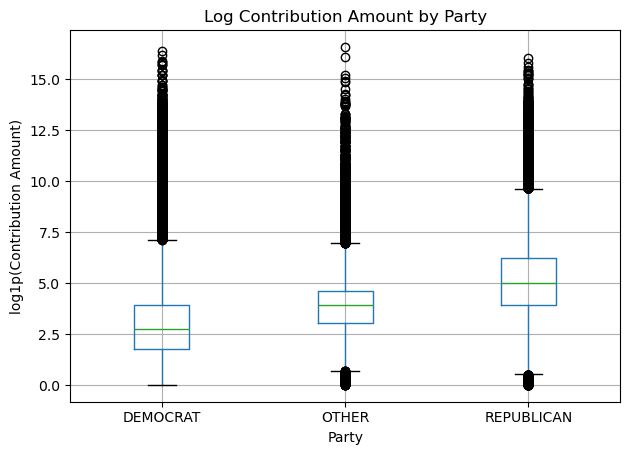

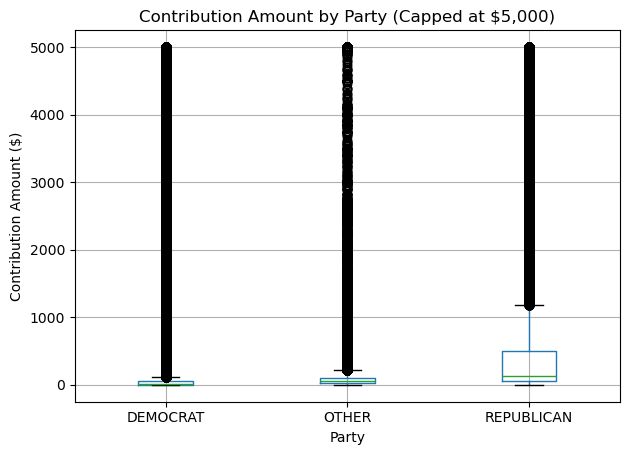

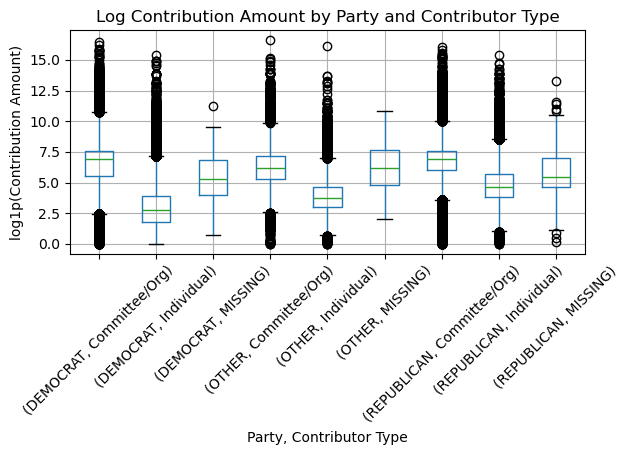

In [6]:
if MAKE_GRAPHS:
    sample_fraction = 0.25

    # Log contribution amount by party -- standard for right-skewed monetary distributions
    amount_log_pd = (
        contrib_model_df
        .select("party_group", F.log1p(F.col("amount")).alias("log_amount"))
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(amount_log_pd) > 0:
        ax = amount_log_pd.boxplot(column="log_amount", by="party_group")
        ax.set_title("Log Contribution Amount by Party")
        ax.set_xlabel("Party")
        ax.set_ylabel("log1p(Contribution Amount)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

    # Raw contribution amount by party, capped at $5,000 (per codebook's own
    # capping convention (Section 6) for the largest itemized contributions)
    amount_capped_pd = (contrib_model_df
        .select("party_group", "amount")
        .filter(F.col("amount") <= 5000)
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(amount_capped_pd) > 0:
        ax = amount_capped_pd.boxplot(column="amount", by="party_group")
        ax.set_title("Contribution Amount by Party (Capped at $5,000)")
        ax.set_xlabel("Party")
        ax.set_ylabel("Contribution Amount ($)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

    # Log contribution amount by party and contributor type
    amount_type_pd = (
        contrib_model_df
        .select("party_group", "contributor_type", F.log1p(F.col("amount")).alias("log_amount"))
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(amount_type_pd) > 0:
        ax = amount_type_pd.boxplot(column="log_amount", by=["party_group", "contributor_type"], rot=45)
        ax.set_title("Log Contribution Amount by Party and Contributor Type")
        ax.set_xlabel("Party, Contributor Type")
        ax.set_ylabel("log1p(Contribution Amount)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

### Density Plot: Contribution Amount by Party

Distribution of contribution amounts by contributor type and party:


+-----------+--------+--------------------+-------------+----------------------+
|party_group|count   |total_amount        |median_amount|90th_percentile_amount|
+-----------+--------+--------------------+-------------+----------------------+
|REPUBLICAN |2693110 |3.6959869145600324E9|150.0        |2000.0                |
|DEMOCRAT   |10717935|3.6259941900399785E9|15.0         |250.0                 |
|OTHER      |1044569 |6.283253162150056E8 |50.0         |320.0                 |
+-----------+--------+--------------------+-------------+----------------------+



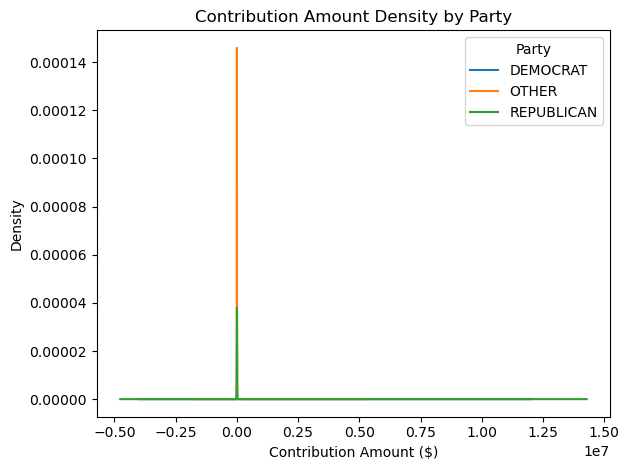

In [15]:
# 4. Distribution of contribution amounts by party -- check for outliers or unexpected patterns
contrib_type_party_amount = (
    contrib_model_df
    .groupBy("party_group")
    .agg(
        F.count("*").alias("count"),
        F.sum("amount").alias("total_amount"),
        F.expr("percentile_approx(amount, 0.5)").alias("median_amount"),
        F.expr("percentile_approx(amount, 0.9)").alias("90th_percentile_amount"),
    )
)
if SHOW_EDA_TABLES:
    print("Distribution of contribution amounts by contributor type and party:")
    show_df(contrib_type_party_amount.orderBy(F.desc("total_amount")), 50)

# density plot of contribution amounts, one line per party group
if MAKE_GRAPHS:
    amounts_pd = (
        contrib_model_df
        .select("party_group", "amount")
        .where(F.col("amount").isNotNull())
        .sample(fraction=0.1, seed=RANDOM_SEED)   
        .toPandas()
    )

    if len(amounts_pd) > 0:
        fig, ax = plt.subplots()
        for party, grp in amounts_pd.groupby("party_group"):
            if grp["amount"].nunique() > 1:  # kde needs some variance
                grp["amount"].plot(kind="kde", ax=ax, label=str(party))
        ax.set_title("Contribution Amount Density by Party")
        ax.set_xlabel("Contribution Amount ($)")
        ax.set_ylabel("Density")
        ax.legend(title="Party")
        plt.tight_layout()
        plt.show()

### Density Plot: Log Contribution Amount by Party

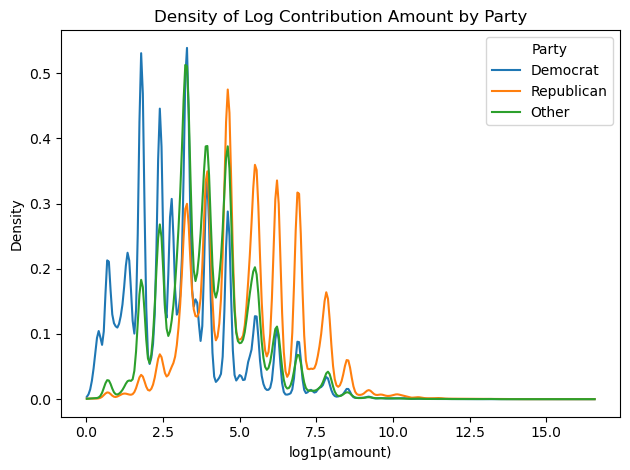

In [10]:
# Density plot of log contribution amount, one curve per party
if MAKE_GRAPHS:
    density_sample_fraction = 0.25
    density_pd = (
        contrib_model_df
        .select("party_group", F.log1p(F.col("amount")).alias("log_amount"))
        .sample(False, density_sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )

    if len(density_pd) > 0:
        grid = np.linspace(density_pd["log_amount"].min(), density_pd["log_amount"].max(), 300)
        fig, ax = plt.subplots()
        for party in ["DEMOCRAT", "REPUBLICAN", "OTHER"]:
            values = density_pd.loc[density_pd["party_group"] == party, "log_amount"].to_numpy()
            if len(values) < 2:
                continue
            ax.plot(grid, gaussian_kde(values)(grid), label=party.title())
        ax.set_title("Density of Log Contribution Amount by Party")
        ax.set_xlabel("log1p(amount)")
        ax.set_ylabel("Density")
        ax.legend(title="Party")
        plt.tight_layout()
        plt.show()

### Top-Decile Density: Log Contribution Amount by Party, Contributor Type, and Transaction Type

Top 10 percentiles of contribution amount by party group ($):
      REPUBLICAN    DEMOCRAT       OTHER
p90      2000.00       250.0       320.0
p91      2000.00       250.0       416.0
p92      2500.00       300.0       500.0
p93      2500.00       500.0       500.0
p94      2500.00       500.0       500.0
p95      2600.00       500.0       900.0
p96      3000.00      1000.0      1000.0
p97      5000.00      1000.0      1100.0
p98      5000.00      2000.0      2500.0
p99     12000.00      2700.0      2700.0
max  13186434.07  74000000.0  20000000.0


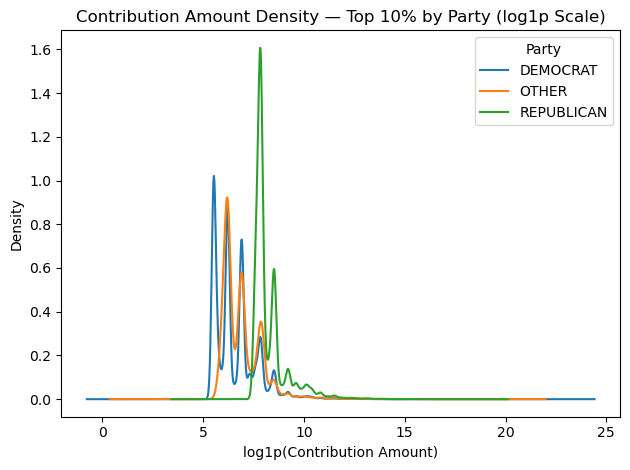

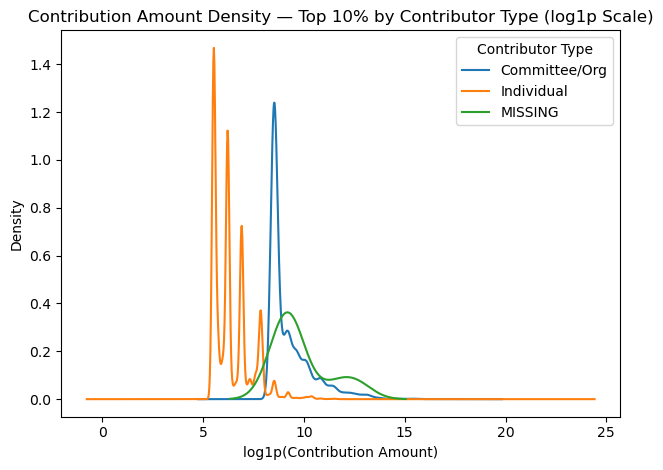

In [18]:
# Top-decile distribution of contribution amounts -- zoom into the tail

percentiles = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
pct_labels = [f"p{int(round(p * 100))}" for p in percentiles]
quantile_array = "array(" + ", ".join(str(p) for p in percentiles) + ")"

# --- TABLE: the top 10 percentiles per party group -------------------------
top_pct_spark = (
    contrib_model_df
    .select("party_group", "amount", F.log1p(F.col("amount")).alias("log_amount"))
    .groupBy("party_group")
    .agg(
        F.count("*").alias("count"),
        F.expr(f"percentile_approx(amount, {quantile_array})").alias("pcts"),
        F.max("amount").alias("p100_max"),   
    )
)

if SHOW_EDA_TABLES:
    raw = top_pct_spark.toPandas()
    top_pct_table = pd.DataFrame(
        {r["party_group"]: r["pcts"] for _, r in raw.iterrows()},
        index=pct_labels,
    )
    top_pct_table.loc["max"] = {
        r["party_group"]: r["p100_max"] for _, r in raw.iterrows()
    }
    print("Top 10 percentiles of contribution amount by party group ($):")
    print(top_pct_table.round(2).to_string())


# --- GRAPH helper: density of just the top 10% of contributions, one line per group
GROUP_COL_DISPLAY_NAMES = {
    "party_group": "Party",
    "contributor_type": "Contributor Type",
    "transaction_type": "Transaction Type",
}

def plot_top_decile_density(group_col):
    display_name = GROUP_COL_DISPLAY_NAMES.get(group_col, group_col)
    threshold_df = (
        contrib_model_df
        .groupBy(group_col)
        .agg(F.expr("percentile_approx(amount, 0.90)").alias("p90"))
    )

    top10_pd = (
        contrib_model_df
        .join(F.broadcast(threshold_df), on=group_col, how="inner")
        .where(F.col("amount") >= F.col("p90"))
        .select(group_col, F.log1p(F.col("amount")).alias("log_amount"))
        .where(F.col("log_amount").isNotNull())
        .sample(fraction=0.1, seed=RANDOM_SEED)  
        .toPandas()
    )

    if len(top10_pd) > 0:
        fig, ax = plt.subplots()
        for grp_val, grp in top10_pd.groupby(group_col):
            if grp["log_amount"].nunique() > 1:  # kde needs some variance
                grp["log_amount"].plot(kind="kde", ax=ax, label=str(grp_val))
        ax.set_title(f"Contribution Amount Density — Top 10% by {display_name} (log1p Scale)")
        ax.set_xlabel("log1p(Contribution Amount)")
        ax.set_ylabel("Density")
        ax.legend(title=display_name)
        plt.tight_layout()
        plt.show()


if MAKE_GRAPHS:
    plot_top_decile_density("party_group")
    plot_top_decile_density("contributor_type")

In [16]:
contrib_model_df.groupBy("contributor_type").count().orderBy(F.desc("count")).show(10, truncate=False)

+-----------------+--------+
|contributor_type |count   |
+-----------------+--------+
|Individual       |13400341|
|Committee/Org    |1053926 |
|MISSING          |1342    |
|FEDERAL:COMMITTEE|3       |
|FEDERAL:SENATE   |2       |
+-----------------+--------+



### Stacked Bar Chart: Party Share by Occupation Group (Top 15 by Volume)

Party share by occupation group:


+------------------------+-----------+-------+----------------+--------------------+
|occupation_group        |party_group|count  |occupation_total|party_pct           |
+------------------------+-----------+-------+----------------+--------------------+
|UNKNOWN                 |DEMOCRAT   |3525130|4627939         |0.7617062368367431  |
|UNKNOWN                 |OTHER      |119468 |4627939         |0.025814514841271678|
|UNKNOWN                 |REPUBLICAN |983341 |4627939         |0.21247924832198523 |
|RETIRED                 |DEMOCRAT   |1319153|2073455         |0.6362100937806704  |
|RETIRED                 |OTHER      |165467 |2073455         |0.07980255177951776 |
|RETIRED                 |REPUBLICAN |588835 |2073455         |0.2839873544398118  |
|OTHER                   |DEMOCRAT   |1027732|1341176         |0.766291672383043   |
|OTHER                   |OTHER      |146436 |1341176         |0.10918477515255269 |
|OTHER                   |REPUBLICAN |167008 |1341176         |0.

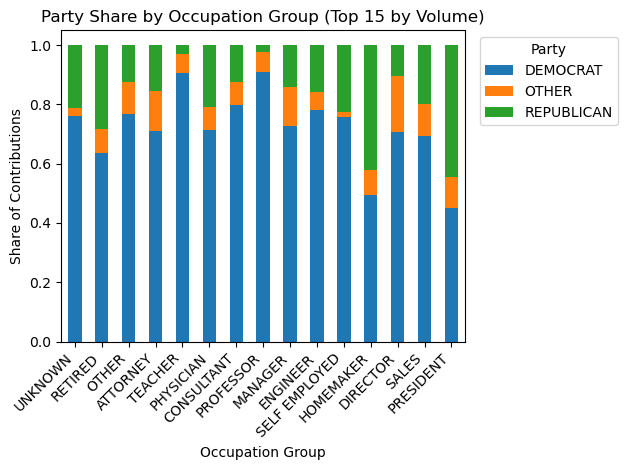

In [17]:
# 1. 100% stacked bar: party share within each occupation group (top 15 by volume)

occupation_party_pct = (
    contrib_model_df
    .groupBy("occupation_group", "party_group")
    .count()
    .withColumn("occupation_total", F.sum("count").over(Window.partitionBy("occupation_group")))
    .withColumn("party_pct", F.col("count") / F.col("occupation_total"))
)

if SHOW_EDA_TABLES:
    print("Party share by occupation group:")
    show_df(occupation_party_pct.orderBy(F.desc("occupation_total"), "occupation_group", "party_group"), 200)

if MAKE_GRAPHS:
    occupation_party_pd = occupation_party_pct.select(
        "occupation_group", "party_group", "party_pct", "occupation_total"
    ).toPandas()
    if len(occupation_party_pd) > 0:
        top_occupations = (
            occupation_party_pd.drop_duplicates("occupation_group")
            .sort_values("occupation_total", ascending=False)
            .head(15)["occupation_group"]
            .tolist()
        )
        plot_df = occupation_party_pd[occupation_party_pd["occupation_group"].isin(top_occupations)]
        pivot_occ_pct = (
            plot_df.pivot_table(index="occupation_group", columns="party_group", values="party_pct", aggfunc="sum")
            .fillna(0)
            .loc[top_occupations]
        )
        ax = pivot_occ_pct.plot(kind="bar", stacked=True, title="Party Share by Occupation Group (Top 15 by Volume)")
        ax.set_xlabel("Occupation Group")
        ax.set_ylabel("Share of Contributions")
        ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

### Heatmap: Party Share of Contribution Amount by Contributor State (Top 20 by Total $)

Party share of contribution amount by contributor state (top 20 by total $):


+-----------------+-----------+--------------------+--------------------+--------------------+
|contributor_state|party_group|total_amount        |state_amount_total  |amount_pct          |
+-----------------+-----------+--------------------+--------------------+--------------------+
|DC               |DEMOCRAT   |8.449117795499986E8 |1.6583344350699987E9|0.5094942019426466  |
|DC               |OTHER      |4.908699902000004E7 |1.6583344350699987E9|0.02960018074878127 |
|DC               |REPUBLICAN |7.643356565E8       |1.6583344350699987E9|0.46090561730857216 |
|CA               |DEMOCRAT   |4.393667257899943E8 |8.67103115749994E8  |0.5067064318065188  |
|CA               |OTHER      |1.7241734941000053E8|8.67103115749994E8  |0.19884295913395433 |
|CA               |REPUBLICAN |2.5531904054999927E8|8.67103115749994E8  |0.29445060905952697 |
|TX               |DEMOCRAT   |3.3080836424000007E8|5.852145773400009E8 |0.565277040335592   |
|TX               |OTHER      |1.2645344160000026E

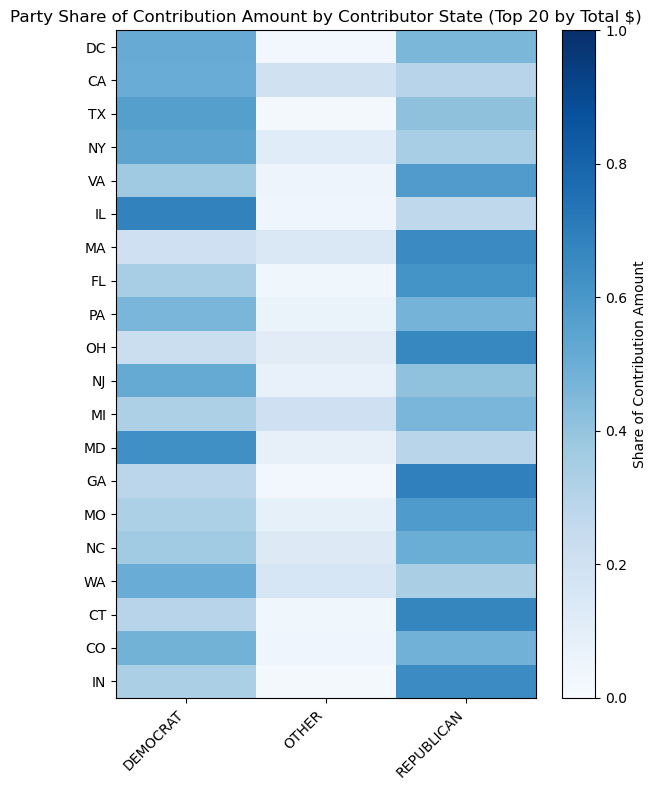

In [19]:
# 2. Heatmap: party share of contribution amount by contributor state (top 20 states by total $)
# Scaled per state (each row sums to 1) instead of showing raw dollar totals -- Other raises far
# less money overall than Democrat/Republican, so an unscaled view would make Other's numbers
# invisible next to the other two and would only show that Democrats raised the most money in
# this dataset. Normalizing within each state instead shows each party's relative share of that
# state's money, so a state that is relatively important to Other still shows up.

state_party_amounts = (
    contrib_model_df
    .groupBy("contributor_state", "party_group")
    .agg(F.sum("amount").alias("total_amount"))
)

state_amount_totals = (
    state_party_amounts
    .groupBy("contributor_state")
    .agg(F.sum("total_amount").alias("state_amount_total"))
    .orderBy(F.desc("state_amount_total"))
)

top_states = [row["contributor_state"] for row in state_amount_totals.limit(20).collect()]

state_party_amount_pct = (
    state_party_amounts
    .join(state_amount_totals, on="contributor_state")
    .withColumn("amount_pct", F.col("total_amount") / F.col("state_amount_total"))
    .filter(F.col("contributor_state").isin(top_states))
)

if SHOW_EDA_TABLES:
    print("Party share of contribution amount by contributor state (top 20 by total $):")
    show_df(state_party_amount_pct.orderBy(F.desc("state_amount_total"), "contributor_state", "party_group"), 100)

if MAKE_GRAPHS:
    state_party_pd = state_party_amount_pct.select("contributor_state", "party_group", "amount_pct").toPandas()
    if len(state_party_pd) > 0:
        heatmap_pivot = state_party_pd.pivot_table(
            index="contributor_state", columns="party_group", values="amount_pct", aggfunc="sum"
        ).fillna(0)
        heatmap_pivot = heatmap_pivot.loc[[s for s in top_states if s in heatmap_pivot.index]]

        fig, ax = plt.subplots(figsize=(6, 8))
        im = ax.imshow(heatmap_pivot.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(heatmap_pivot.columns)))
        ax.set_xticklabels(heatmap_pivot.columns, rotation=45, ha="right")
        ax.set_yticks(range(len(heatmap_pivot.index)))
        ax.set_yticklabels(heatmap_pivot.index)
        ax.set_title("Party Share of Contribution Amount by Contributor State (Top 20 by Total $)")
        fig.colorbar(im, ax=ax, label="Share of Contribution Amount")
        plt.tight_layout()
        plt.show()

### Grouped Bar Chart: Median Log Contribution Amount by Seat Group and Party (Top 10 by Volume)

Median log contribution amount by seat group and party:


+-----------------------+-----------+------------------+-------+
|seat_group             |party_group|median_log_amount |rows   |
+-----------------------+-----------+------------------+-------+
|FEDERAL:COMMITTEE      |DEMOCRAT   |2.3978952727983707|4947708|
|FEDERAL:PRESIDENT      |DEMOCRAT   |3.258096538021482 |2309182|
|FEDERAL:HOUSE          |DEMOCRAT   |3.044522437723423 |1261413|
|FEDERAL:SENATE         |DEMOCRAT   |2.3978952727983707|1089164|
|FEDERAL:PRESIDENT      |REPUBLICAN |4.501474949649326 |637636 |
|FEDERAL:PRESIDENT      |OTHER      |3.367295829986474 |585198 |
|FEDERAL:HOUSE          |REPUBLICAN |6.2166061010848646|479721 |
|FEDERAL:COMMITTEE      |REPUBLICAN |4.61512051684126  |448292 |
|STATE:LOWER            |DEMOCRAT   |5.017279836814924 |341414 |
|STATE:LOWER            |REPUBLICAN |5.5254529391317835|310250 |
|FEDERAL:COMMITTEE      |OTHER      |3.9318256327243257|280416 |
|STATE:UPPER            |DEMOCRAT   |4.61512051684126  |213352 |
|FEDERAL:SENATE         |

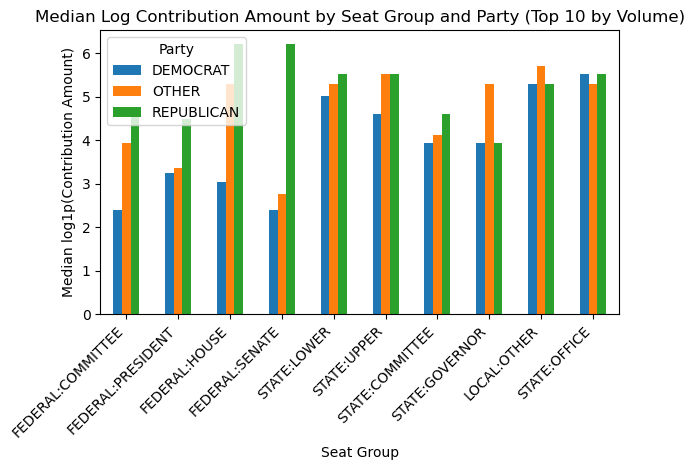

In [21]:
# Grouped bar: median log contribution amount by seat group and party (top 10 seats by volume)

seat_party_median_amount = (
    contrib_model_df
    .withColumn("log_amount", F.log1p(F.col("amount")))
    .groupBy("seat_group", "party_group")
    .agg(
        F.expr("percentile_approx(log_amount, 0.5)").alias("median_log_amount"),
        F.count("*").alias("rows"),
    )
)

seat_totals_amount = (
    seat_party_median_amount
    .groupBy("seat_group")
    .agg(F.sum("rows").alias("seat_total"))
    .orderBy(F.desc("seat_total"))
)

top_seats_amount = [row["seat_group"] for row in seat_totals_amount.limit(10).collect()]

if SHOW_EDA_TABLES:
    print("Median log contribution amount by seat group and party:")
    show_df(seat_party_median_amount.orderBy(F.desc("rows")), 50)

if MAKE_GRAPHS:
    seat_median_pd = (
        seat_party_median_amount
        .filter(F.col("seat_group").isin(top_seats_amount))
        .select("seat_group", "party_group", "median_log_amount")
        .toPandas()
    )
    if len(seat_median_pd) > 0:
        pivot_median = (
            seat_median_pd.pivot_table(index="seat_group", columns="party_group", values="median_log_amount", aggfunc="sum")
            .loc[[s for s in top_seats_amount if s in seat_median_pd["seat_group"].unique()]]
        )
        ax = pivot_median.plot(kind="bar", title="Median Log Contribution Amount by Seat Group and Party (Top 10 by Volume)")
        ax.set_xlabel("Seat Group")
        ax.set_ylabel("Median log1p(Contribution Amount)")
        ax.legend(title="Party")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

### Stacked Bar Chart: Party Share by Seat Group (Primary)

Party share by seat_group_primary:
+------------------+-----------+-------+-------------+-------------------+
|seat_group_primary|party_group|count  |primary_total|party_pct          |
+------------------+-----------+-------+-------------+-------------------+
|FEDERAL           |DEMOCRAT   |9617111|12255697     |0.7847053496834983 |
|FEDERAL           |OTHER      |876408 |12255697     |0.07151025355799838|
|FEDERAL           |REPUBLICAN |1762178|12255697     |0.1437843967585034 |
|STATE             |DEMOCRAT   |947327 |1934891      |0.4896022566645873 |
|STATE             |OTHER      |128212 |1934891      |0.06626316417824053|
|STATE             |REPUBLICAN |859352 |1934891      |0.44413457915717214|
|LOCAL             |DEMOCRAT   |151470 |262240       |0.5776006711409396 |
|LOCAL             |OTHER      |39811  |262240       |0.15181131787675411|
|LOCAL             |REPUBLICAN |70959  |262240       |0.2705880109823063 |
|OTHER             |DEMOCRAT   |2027   |2786         |0.727566403

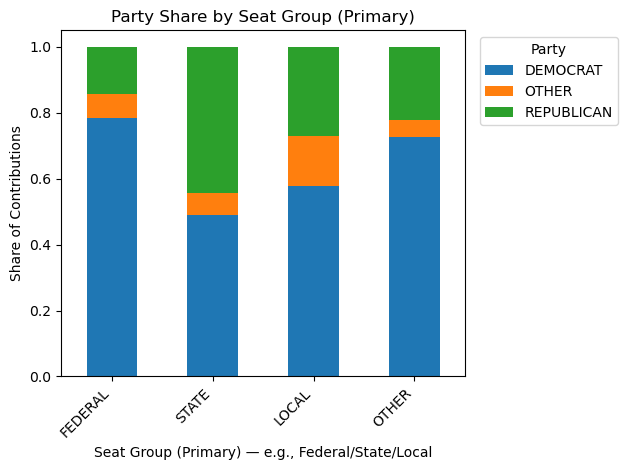

Counts by seat_group_primary:
+------------------+--------+
|seat_group_primary|   count|
+------------------+--------+
|           FEDERAL|12255697|
|             STATE| 1934891|
|             LOCAL|  262240|
|             OTHER|    2786|
+------------------+--------+



In [22]:
# Party share by seat_group_primary
seat_primary_party_pct = (
    contrib_model_df
    .groupBy("seat_group_primary", "party_group")
    .count()
    .withColumn("primary_total", F.sum("count").over(Window.partitionBy("seat_group_primary")))
    .withColumn("party_pct", F.col("count") / F.col("primary_total"))
)

if SHOW_EDA_TABLES:
    print("Party share by seat_group_primary:")
    show_df(seat_primary_party_pct.orderBy(F.desc("primary_total"), "seat_group_primary", "party_group"), 200)

if MAKE_GRAPHS:
    seat_primary_party_pd = seat_primary_party_pct.select(
        "seat_group_primary", "party_group", "party_pct", "primary_total"
    ).toPandas()
    if len(seat_primary_party_pd) > 0:
        order = (
            seat_primary_party_pd.drop_duplicates("seat_group_primary")
            .sort_values("primary_total", ascending=False)["seat_group_primary"]
            .tolist()
        )
        pivot_primary = (
            seat_primary_party_pd.pivot_table(index="seat_group_primary", columns="party_group", values="party_pct", aggfunc="sum")
            .fillna(0)
            .loc[order]
        )
        ax = pivot_primary.plot(kind="bar", stacked=True, title="Party Share by Seat Group (Primary)")
        ax.set_xlabel("Seat Group (Primary) — e.g., Federal/State/Local")
        ax.set_ylabel("Share of Contributions")
        ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
if SHOW_EDA_TABLES:
    print("Counts by seat_group_primary:")
    contrib_model_df.groupBy("seat_group_primary").count().show()

### Stacked Bar Chart: Party Share by Seat Group (Secondary) (Top 15 by Volume)

Party share by seat_group_secondary:


+------------------------+-----------+-------+---------------+---------------------+
|seat_group_secondary    |party_group|count  |secondary_total|party_pct            |
+------------------------+-----------+-------+---------------+---------------------+
|COMMITTEE               |DEMOCRAT   |5089680|6028509        |0.8442684584198182   |
|COMMITTEE               |OTHER      |377748 |6028509        |0.06266026972838558  |
|COMMITTEE               |REPUBLICAN |561081 |6028509        |0.09307127185179619  |
|PRESIDENT               |DEMOCRAT   |2309182|3532016        |0.653785826564772    |
|PRESIDENT               |OTHER      |585198 |3532016        |0.16568384741178976  |
|PRESIDENT               |REPUBLICAN |637636 |3532016        |0.18053032602343816  |
|HOUSE                   |DEMOCRAT   |1261413|1744443        |0.7231035923787708   |
|HOUSE                   |OTHER      |3309   |1744443        |0.0018968805515571447|
|HOUSE                   |REPUBLICAN |479721 |1744443        |0.2

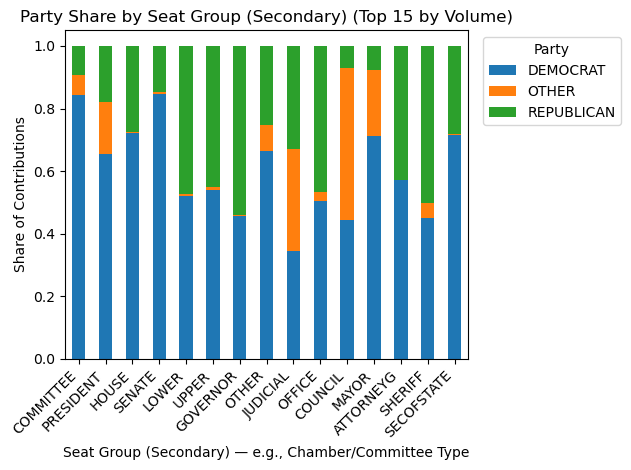

In [23]:
# EDA: party share by seat_group_secondary (top 15 by volume)
seat_secondary_party_pct = (
    contrib_model_df
    .groupBy("seat_group_secondary", "party_group")
    .count()
    .withColumn("secondary_total", F.sum("count").over(Window.partitionBy("seat_group_secondary")))
    .withColumn("party_pct", F.col("count") / F.col("secondary_total"))
)

if SHOW_EDA_TABLES:
    print("Party share by seat_group_secondary:")
    show_df(seat_secondary_party_pct.orderBy(F.desc("secondary_total"), "seat_group_secondary", "party_group"), 200)

if MAKE_GRAPHS:
    seat_secondary_party_pd = seat_secondary_party_pct.select(
        "seat_group_secondary", "party_group", "party_pct", "secondary_total"
    ).toPandas()
    if len(seat_secondary_party_pd) > 0:
        top_secondary = (
            seat_secondary_party_pd.drop_duplicates("seat_group_secondary")
            .sort_values("secondary_total", ascending=False)
            .head(15)["seat_group_secondary"]
            .tolist()
        )
        plot_df = seat_secondary_party_pd[seat_secondary_party_pd["seat_group_secondary"].isin(top_secondary)]
        pivot_secondary = (
            plot_df.pivot_table(index="seat_group_secondary", columns="party_group", values="party_pct", aggfunc="sum")
            .fillna(0)
            .loc[top_secondary]
        )
        ax = pivot_secondary.plot(kind="bar", stacked=True, title="Party Share by Seat Group (Secondary) (Top 15 by Volume)")
        ax.set_xlabel("Seat Group (Secondary) — e.g., Chamber/Committee Type")
        ax.set_ylabel("Share of Contributions")
        ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

# Data Splitting, Cross-Validation, Hyperparameter Tuning, and Modeling

Model construction, evaluation, and K-fold cross-validation of hyperparameters. This section uses a held-out test set and runs cross-validation only on the training data.

In [6]:
def add_donor_split(
    df: DataFrame,
    id_col: str,
    test_fraction: float,
    seed: int,
    split_col: str = "split",
    num_buckets: int = 1000,
) -> DataFrame:
    # Same donor always hashes to the same bucket -> always lands on the same side.
    bucket = F.pmod(F.hash(F.col(id_col), F.lit(seed)), F.lit(num_buckets))
    threshold = int(round(test_fraction * num_buckets))
    return df.withColumn(split_col, F.when(bucket < threshold, F.lit("test")).otherwise(F.lit("train")))

contrib_model_df = add_donor_split(contrib_model_df, "bonica_cid", TEST_FRACTION, RANDOM_SEED)

print("Rows by split:")
show_df(contrib_model_df.groupBy("split").count(), 5)

train_donor_count = contrib_model_df.filter(F.col("split") == "train").select("bonica_cid").distinct().count()
test_donor_count = contrib_model_df.filter(F.col("split") == "test").select("bonica_cid").distinct().count()
print("Train distinct donors:", train_donor_count, " Test distinct donors:", test_donor_count)

# Sanity check -- should always be 0 by construction, but confirm it.
overlap_count = (
    contrib_model_df.filter(F.col("split") == "train").select("bonica_cid").distinct()
    .intersect(contrib_model_df.filter(F.col("split") == "test").select("bonica_cid").distinct())
    .count()
)
print("Donor overlap between train/test (should be 0):", overlap_count)

print("Party balance by split (should be roughly similar train vs test):")
show_df(contrib_model_df.groupBy("split", "party_group").count().orderBy("split", F.desc("count")), 20)

# Refit occupation_group here, train-only, before contrib_train_df/contrib_test_df are
# materialized below -- the build-cell fit above (used for EDA and the schema checks) was
# fit on the full dataset, which would leak test-set occupation vocabulary into the model
# features. This overwrites occupation_group with a leak-safe version for modeling.
train_only_df = contrib_model_df.filter(F.col("split") == "train")

contrib_model_df, occupation_canonical, occupation_fuzzy_map = build_bucket_with_fuzzy_match(
    fit_df=train_only_df,       # vocabulary/fuzzy-map fit on TRAIN ONLY
    apply_df=contrib_model_df,  # applied to both train and test rows
    col_name="contributor_occupation_clean",
    top_n=OCCUPATION_TOP_N,
    out_col="occupation_group",
    synonym_map=OCCUPATION_SYNONYMS,
    contains_exclude=FUZZY_CONTAINS_EXCLUDE,
)

# ---- Step 7: donor-level feature/label wiring for the ContribDB party model ----
# CONTRIB_TRAIN_PARQUET / CONTRIB_TEST_PARQUET are now defined earlier, in the config cell,
# so the raw-file download cell can check them too.

contrib_model_df = contrib_model_df.withColumn("log_amount", F.log1p(F.col("amount")))

def materialize_split(df: DataFrame, out_path: Path, force: bool = False) -> DataFrame:
    if not force and parquet_has_data(out_path):
        return spark.read.parquet(str(out_path))
    df.repartition(MODEL_PARTITIONS).write.mode("overwrite").option("compression", "snappy").parquet(str(out_path))
    return spark.read.parquet(str(out_path))

contrib_train_df = materialize_split(contrib_model_df.filter(F.col("split") == "train"), CONTRIB_TRAIN_PARQUET)
contrib_test_df = materialize_split(contrib_model_df.filter(F.col("split") == "test"), CONTRIB_TEST_PARQUET)

contrib_model_df.unpersist()
contrib_train_df = contrib_train_df.cache()
contrib_test_df = contrib_test_df.cache()

print("Contrib train rows:", contrib_train_df.count(), " Contrib test rows:", contrib_test_df.count())

# NOTE: no manual label indexing here -- build_preprocess_stages() (in the modeling section below)
# already includes StringIndexer(inputCol="party_group", outputCol="label", ...) as its first
# pipeline stage. Adding a "label" column here too would collide with that stage's output column.
# contrib_train_df/contrib_test_df just need "party_group" present, which they already have.

# ---- Namespaced feature lists ----
contrib_numeric_features = ["log_amount"]
contrib_categorical_features = [
    "occupation_group",
    "transaction_type",
    "seat_group_primary",
    "seat_group_secondary",
    "contributor_state",
    "recipient_state_group",
    "election_type_group",
    "contributor_gender",
    "contributor_type",
]

print("Contrib numeric features:", contrib_numeric_features)
print("Contrib categorical features:", contrib_categorical_features)


Rows by split:
+-----+--------+
|split|count   |
+-----+--------+
|train|11564691|
|test |2890923 |
+-----+--------+



Train distinct donors: 2715340  Test distinct donors: 679908


Donor overlap between train/test (should be 0): 0
Party balance by split (should be roughly similar train vs test):


/apps/software/standard/core/pyspark/4.0.0-py3.11/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


+-----+-----------+-------+
|split|party_group|count  |
+-----+-----------+-------+
|test |DEMOCRAT   |2142807|
|test |REPUBLICAN |538429 |
|test |OTHER      |209687 |
|train|DEMOCRAT   |8575128|
|train|REPUBLICAN |2154681|
|train|OTHER      |834882 |
+-----+-----------+-------+



[Stage 55:=================================================>      (14 + 2) / 16]

Contrib train rows: 5782941  Contrib test rows: 1445544
Contrib numeric features: ['log_amount']
Contrib categorical features: ['occupation_group', 'transaction_type', 'seat_group_primary', 'seat_group_secondary', 'contributor_state', 'recipient_state_group', 'election_type_group', 'contributor_gender', 'contributor_type']


## Initialize Cross Validation Evalutation

In [7]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_weighted_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_weighted_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# Cross-validation optimizes weighted F1.
cv_evaluator = evaluator_f1

def build_preprocess_stages(
    numeric_cols,
    categorical_cols,
    output_features_col="features",
    scale_numeric=True,
    bucket_numeric_col=None,
    bucket_splits=None,
):
    '''
    Build a list of Spark ML pipeline stages for preprocessing the contrib model features.
    Includes:
    - StringIndexer for the label column (party_group)
    - StringIndexer for each categorical feature
    - OneHotEncoder for each categorical feature
    - VectorAssembler to combine numeric and encoded categorical features into a single feature vector
    - Optional StandardScaler for numeric features
    - Optional Bucketizer that discretizes one numeric column (bucket_numeric_col, with cut
      points bucket_splits) into a one-hot bucket feature instead of passing it through as a
      raw continuous value -- multinomial Naive Bayes expects count-like/categorical inputs,
      not a continuous log-dollar amount, so the NB pipeline uses this; other models leave it None.
    '''

    label_indexer = StringIndexer(inputCol="party_group", outputCol="label", handleInvalid="skip")

    numeric_cols = list(numeric_cols)
    ohe_input_cols = [f"{c}_idx" for c in categorical_cols]
    ohe_output_cols = [f"{c}_ohe" for c in categorical_cols]

    cat_indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in categorical_cols
    ]

    bucket_stages = []
    if bucket_numeric_col is not None:
        bucket_col = f"{bucket_numeric_col}_bucket"
        bucket_stages.append(
            Bucketizer(
                splits=bucket_splits,
                inputCol=bucket_numeric_col,
                outputCol=bucket_col,
                handleInvalid="keep"
            )
        )
        # Bucketizer already emits a 0-indexed bucket number, so it feeds OneHotEncoder
        # directly -- no StringIndexer needed -- and it drops out of the numeric passthrough.
        numeric_cols = [c for c in numeric_cols if c != bucket_numeric_col]
        ohe_input_cols = ohe_input_cols + [bucket_col]
        ohe_output_cols = ohe_output_cols + [f"{bucket_numeric_col}_ohe"]

    encoder = OneHotEncoder(
        inputCols=ohe_input_cols,
        outputCols=ohe_output_cols,
        handleInvalid="keep"
    )

    assembler_inputs = numeric_cols + ohe_output_cols

    assembler = VectorAssembler(
        inputCols=assembler_inputs,
        outputCol="features_raw",
        handleInvalid="keep"
    )

    stages = [label_indexer] + cat_indexers + bucket_stages + [encoder, assembler]

    if scale_numeric:
        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol=output_features_col,
            withMean=False,
            withStd=True
        )
        stages.append(scaler)

    return stages

def get_label_names_from_pipeline_model(model):
    '''
    Extract the label names from a fitted Spark ML pipeline model.
    (Assumes the first stage is a StringIndexer for the label column.)
    '''
    for st in model.stages:
        if hasattr(st, "labels"):
            return list(st.labels)
    return []

def compute_multiclass_ovr_auc(pred_df, labels):
    if "probability" not in pred_df.columns:
        return {"macro_ovr_auc": None, "weighted_ovr_auc": None}

    label_counts = {
        row["label"]: row["count"]
        for row in pred_df.groupBy("label").count().collect()
    }
    total = sum(label_counts.values())
    if total == 0:
        return {"macro_ovr_auc": None, "weighted_ovr_auc": None}

    prob_df = pred_df.withColumn("prob_array", vector_to_array(F.col("probability")))

    binary_eval = BinaryClassificationEvaluator(
        labelCol="binary_label",
        rawPredictionCol="score",
        metricName="areaUnderROC"
    )

    aucs = []
    weighted_parts = []

    for i, label_name in enumerate(labels):
        tmp = (
            prob_df
            .select(
                F.when(F.col("label") == float(i), 1.0).otherwise(0.0).alias("binary_label"),
                F.col("prob_array")[i].alias("score")
            )
            .filter(F.col("score").isNotNull())
        )

        pos_neg = tmp.groupBy("binary_label").count().collect()
        if len(pos_neg) < 2:
            auc = None
        else:
            auc = binary_eval.evaluate(tmp)

        if auc is not None:
            aucs.append(float(auc))
            weighted_parts.append(float(auc) * (label_counts.get(float(i), 0) / total))

    return {
        "macro_ovr_auc": sum(aucs) / len(aucs) if aucs else None,
        "weighted_ovr_auc": sum(weighted_parts) if weighted_parts else None,
    }

def evaluate_predictions(pred_df, model_name, labels):
    '''
    Evaluate predictions from a Spark ML model and return a dictionary of metrics.
    Metrics include accuracy, weighted F1, weighted precision, weighted recall, and 
    macro/weighted one-vs-rest AU ROC if available.
    '''
    metrics = {
        "model": model_name,
        "accuracy": evaluator_acc.evaluate(pred_df),
        "weighted_f1": evaluator_f1.evaluate(pred_df),
        "weighted_precision": evaluator_weighted_precision.evaluate(pred_df),
        "weighted_recall": evaluator_weighted_recall.evaluate(pred_df),
    }

    try:
        metrics.update(compute_multiclass_ovr_auc(pred_df, labels))
    except Exception as e:
        print(f"AUROC could not be computed for {model_name}: {e}")
        metrics["macro_ovr_auc"] = None
        metrics["weighted_ovr_auc"] = None

    return metrics

def confusion_table(pred_df, labels):
    '''
    Build a confusion table DataFrame from predictions.
    '''
    mapping = spark.createDataFrame(
        [(float(i), label) for i, label in enumerate(labels)],
        ["label_index", "label_name"]
    )

    pred_mapping = spark.createDataFrame(
        [(float(i), label) for i, label in enumerate(labels)],
        ["prediction_index", "prediction_name"]
    )

    return (
        pred_df
        .groupBy("label", "prediction")
        .count()
        .join(mapping, F.col("label") == F.col("label_index"), "left")
        .join(pred_mapping, F.col("prediction") == F.col("prediction_index"), "left")
        .select("label_name", "prediction_name", "count")
        .orderBy("label_name", "prediction_name")
    )

def cv_results_table(cv_model, param_names, model_name):
    '''
    Build a DataFrame summarizing cross-validation results from a fitted CrossValidator model.
    
    param_names: list of tuples (Param, display_name) for the parameters to include in the table.
    '''
    rows = []
    for param_map, metric in zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics):
        row = {"model": model_name, "cv_weighted_f1": float(metric)}
        for param_obj, display_name in param_names:
            row[display_name] = str(param_map.get(param_obj, None))
        rows.append(row)

    if not rows:
        rows = [{"model": model_name, "cv_weighted_f1": None}]

    return spark.createDataFrame(pd.DataFrame(rows))

In [8]:
def get_stage_by_type(pipeline_model, type_name: str):
    for st in pipeline_model.stages:
        if st.__class__.__name__ == type_name:
            return st
    return None

def get_stages_by_type(pipeline_model, type_name: str):
    return [st for st in pipeline_model.stages if st.__class__.__name__ == type_name]

def build_feature_names_from_pipeline_model(pipeline_model, numeric_cols, categorical_cols):
    '''
    Reconstructs the feature vector names after:
    StringIndexer -> OneHotEncoder -> VectorAssembler.
    Numeric features appear first. Then OHE categorical levels are expanded.
    '''

    feature_names = list(numeric_cols)

    # StringIndexerModels have inputCol and labels.
    indexer_models = {
        st.getInputCol(): list(st.labels)
        for st in pipeline_model.stages
        if st.__class__.__name__ == "StringIndexerModel" and st.getInputCol() in categorical_cols
    }

    # OHE usually drops the last category by default. If dropLast=True, vector size is len(labels)-1.
    encoder_model = get_stage_by_type(pipeline_model, "OneHotEncoderModel")
    drop_last = True
    category_sizes = None
    if encoder_model is not None:
        try:
            drop_last = encoder_model.getDropLast()
        except Exception:
            drop_last = True
        try:
            category_sizes = list(encoder_model.categorySizes)
        except Exception:
            category_sizes = None

    for idx, c in enumerate(categorical_cols):
        labels = indexer_models.get(c, [])
        if category_sizes is not None and idx < len(category_sizes):
            size = int(category_sizes[idx])
        else:
            size = max(len(labels) - 1, 1) if drop_last else len(labels)

        for j in range(size):
            if j < len(labels):
                feature_names.append(f"{c}={labels[j]}")
            else:
                feature_names.append(f"{c}=__unknown_{j}")

    return feature_names

def random_forest_feature_importance_df(cv_model, numeric_cols, categorical_cols, model_name="Random Forest"):
    '''
    Extracts feature importance from a fitted RandomForestClassifier model within a Spark ML pipeline.
    Returns a DataFrame with columns: model, feature, importance.
    '''
    best_pipeline = cv_model.bestModel
    rf_model = best_pipeline.stages[-1]

    feature_names = build_feature_names_from_pipeline_model(best_pipeline, numeric_cols, categorical_cols)
    importances = rf_model.featureImportances.toArray().tolist()

    # Align lengths safely.
    n = min(len(feature_names), len(importances))
    rows = [(model_name, feature_names[i], float(importances[i])) for i in range(n)]

    # Add unnamed features if Spark vector is longer than reconstructed names.
    if len(importances) > len(feature_names):
        for i in range(len(feature_names), len(importances)):
            rows.append((model_name, f"feature_{i}", float(importances[i])))

    return spark.createDataFrame(rows, ["model", "feature", "importance"]).orderBy(F.desc("importance"))

def logistic_coefficient_importance_df(cv_model, numeric_cols, categorical_cols, model_name="Logistic Regression"):
    '''
    For multinomial logistic regression, coefficientMatrix is classes x features.
    We summarize feature importance as the mean absolute coefficient across classes.
    '''
    best_pipeline = cv_model.bestModel
    lr_model = best_pipeline.stages[-1]

    feature_names = build_feature_names_from_pipeline_model(best_pipeline, numeric_cols, categorical_cols)
    coef_matrix = lr_model.coefficientMatrix.toArray()

    mean_abs = abs(coef_matrix).mean(axis=0).tolist()

    n = min(len(feature_names), len(mean_abs))
    rows = [(model_name, feature_names[i], float(mean_abs[i])) for i in range(n)]

    if len(mean_abs) > len(feature_names):
        for i in range(len(feature_names), len(mean_abs)):
            rows.append((model_name, f"feature_{i}", float(mean_abs[i])))

    return spark.createDataFrame(rows, ["model", "feature", "mean_abs_coefficient"]).orderBy(F.desc("mean_abs_coefficient"))

def group_ohe_importance(importance_df: DataFrame, value_col: str):
    '''
    Groups one-hot encoded feature levels back to the original feature name.
    Example: state_group=CA, state_group=NY -> state_group.
    '''
    grouped = (
        importance_df
        .withColumn(
            "feature_group",
            F.when(F.col("feature").contains("="), F.split(F.col("feature"), "=").getItem(0))
             .otherwise(F.col("feature"))
        )
        .groupBy("model", "feature_group")
        .agg(F.sum(F.col(value_col)).alias(f"grouped_{value_col}"))
        .orderBy(F.desc(f"grouped_{value_col}"))
    )
    return grouped

# Model 1: Benchmark Logistic Regression with CV

In [27]:
benchmark_numeric = [c for c in ["log_amount"] if c in contrib_numeric_features]
benchmark_categorical = [c for c in ["seat_group_primary"] if c in contrib_categorical_features]

benchmark_preprocess = build_preprocess_stages(
    benchmark_numeric,
    benchmark_categorical,
    output_features_col="features",
    scale_numeric=True
)

benchmark_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=30
)

benchmark_pipeline = Pipeline(stages=benchmark_preprocess + [benchmark_lr])

if FAST_CV:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.05])
        .addGrid(benchmark_lr.elasticNetParam, [0.75])
        .build()
    )
else:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.01, 0.05, 0.1])
        .addGrid(benchmark_lr.elasticNetParam, [0.0, 0.5])
        .build()
    )

benchmark_cv = CrossValidator(
    estimator=benchmark_pipeline,
    estimatorParamMaps=benchmark_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

benchmark_cv_model = benchmark_cv.fit(contrib_train_df)
benchmark_pred = benchmark_cv_model.transform(contrib_test_df)
benchmark_labels = get_label_names_from_pipeline_model(benchmark_cv_model.bestModel)

benchmark_metrics = evaluate_predictions(benchmark_pred, "Benchmark Logistic Regression", benchmark_labels)
benchmark_metrics

26/08/05 22:32:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/08/05 22:32:32 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

{'model': 'Benchmark Logistic Regression',
 'accuracy': 0.7473414852816656,
 'weighted_f1': 0.7007288672190968,
 'weighted_precision': 0.6715741712634447,
 'weighted_recall': 0.7473414852816656,
 'macro_ovr_auc': 0.746020386510151,
 'weighted_ovr_auc': 0.7817170795556593}

In [13]:
# Benchmark CV sensitivity table and confusion matrix
benchmark_cv_table = cv_results_table(
    benchmark_cv_model,
    [(benchmark_lr.regParam, "regParam"), (benchmark_lr.elasticNetParam, "elasticNetParam")],
    "Benchmark Logistic Regression"
).orderBy(F.desc("cv_weighted_f1"))

show_df(benchmark_cv_table, 50)
show_df(confusion_table(benchmark_pred, benchmark_labels), 100)

+-----------------------------+------------------+--------+---------------+
|model                        |cv_weighted_f1    |regParam|elasticNetParam|
+-----------------------------+------------------+--------+---------------+
|Benchmark Logistic Regression|0.7027055671479551|0.0     |0.0            |
|Benchmark Logistic Regression|0.7027055671479551|0.0     |0.5            |
|Benchmark Logistic Regression|0.702558219097222 |0.01    |0.0            |
|Benchmark Logistic Regression|0.7023838518823573|0.01    |0.5            |
|Benchmark Logistic Regression|0.6926592770260259|0.05    |0.0            |
|Benchmark Logistic Regression|0.6870388684474552|0.1     |0.0            |
|Benchmark Logistic Regression|0.682841785952383 |0.05    |0.5            |
|Benchmark Logistic Regression|0.6484510141275357|0.1     |0.5            |
+-----------------------------+------------------+--------+---------------+



+----------+---------------+------+
|label_name|prediction_name|count |
+----------+---------------+------+
|DEMOCRAT  |DEMOCRAT       |995197|
|DEMOCRAT  |REPUBLICAN     |76295 |
|OTHER     |DEMOCRAT       |96821 |
|OTHER     |REPUBLICAN     |8136  |
|REPUBLICAN|DEMOCRAT       |183977|
|REPUBLICAN|REPUBLICAN     |85118 |
+----------+---------------+------+



# Model 2: Full Multinomial Logistic Regression with CV

In [16]:
full_lr_preprocess = build_preprocess_stages(
    contrib_numeric_features,
    contrib_categorical_features,
    output_features_col="features",
    scale_numeric=True
)

full_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=30
)

full_lr_pipeline = Pipeline(stages=full_lr_preprocess + [full_lr])

if FAST_CV:
    full_lr_grid = (
        ParamGridBuilder()
        .addGrid(full_lr.regParam, [0.01, 0.05])
        .addGrid(full_lr.elasticNetParam, [0.0, 0.75])
        .build()
    )
else:
    full_lr_grid = (
        ParamGridBuilder()
        .addGrid(full_lr.regParam, [0.001, 0.01, 0.1])
        .addGrid(full_lr.elasticNetParam, [0.0, 0.5, 1.0])
        .build()
    )

full_lr_cv = CrossValidator(
    estimator=full_lr_pipeline,
    estimatorParamMaps=full_lr_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

full_lr_cv_model = full_lr_cv.fit(contrib_train_df)
full_lr_pred = full_lr_cv_model.transform(contrib_test_df)
full_lr_labels = get_label_names_from_pipeline_model(full_lr_cv_model.bestModel)

full_lr_metrics = evaluate_predictions(full_lr_pred, "Full Multinomial Logistic Regression", full_lr_labels)
full_lr_metrics

{'model': 'Full Multinomial Logistic Regression',
 'accuracy': 0.8360264371060306,
 'weighted_f1': 0.830464307485302,
 'weighted_precision': 0.8288844961198618,
 'weighted_recall': 0.8360264371060308,
 'macro_ovr_auc': 0.9292152313603276,
 'weighted_ovr_auc': 0.9164840525494389}

In [17]:
full_lr_cv_table = cv_results_table(
    full_lr_cv_model,
    [(full_lr.regParam, "regParam"), (full_lr.elasticNetParam, "elasticNetParam")],
    "Full Multinomial Logistic Regression"
).orderBy(F.desc("cv_weighted_f1"))

show_df(full_lr_cv_table, 100)
show_df(confusion_table(full_lr_pred, full_lr_labels), 100)

+------------------------------------+------------------+--------+---------------+
|model                               |cv_weighted_f1    |regParam|elasticNetParam|
+------------------------------------+------------------+--------+---------------+
|Full Multinomial Logistic Regression|0.8314987892147072|0.001   |0.0            |
|Full Multinomial Logistic Regression|0.829419573187708 |0.001   |0.5            |
|Full Multinomial Logistic Regression|0.8276844532658841|0.001   |1.0            |
|Full Multinomial Logistic Regression|0.8249275623047737|0.01    |0.0            |
|Full Multinomial Logistic Regression|0.8007298627569579|0.01    |0.5            |
|Full Multinomial Logistic Regression|0.8005996861370271|0.1     |0.0            |
|Full Multinomial Logistic Regression|0.7831401770588999|0.01    |1.0            |
|Full Multinomial Logistic Regression|0.6883812360261979|0.1     |0.5            |
|Full Multinomial Logistic Regression|0.6378325591683157|0.1     |1.0            |
+---

+----------+---------------+------+
|label_name|prediction_name|count |
+----------+---------------+------+
|DEMOCRAT  |DEMOCRAT       |988099|
|DEMOCRAT  |OTHER          |4418  |
|DEMOCRAT  |REPUBLICAN     |78975 |
|OTHER     |DEMOCRAT       |21463 |
|OTHER     |OTHER          |79907 |
|OTHER     |REPUBLICAN     |3587  |
|REPUBLICAN|DEMOCRAT       |125452|
|REPUBLICAN|OTHER          |3136  |
|REPUBLICAN|REPUBLICAN     |140507|
+----------+---------------+------+



# Model 3: Random Forest with CV

In [12]:
rf_preprocess = build_preprocess_stages(
    contrib_numeric_features,
    contrib_categorical_features,
    output_features_col="features",
    scale_numeric=False
)

rf = RandomForestClassifier(
    featuresCol="features_raw",
    labelCol="label",
    seed=RANDOM_SEED
)

rf_pipeline = Pipeline(stages=rf_preprocess + [rf])

if FAST_CV:
    rf_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50])
        .addGrid(rf.maxDepth, [5])
        .build()
    )
else:
    rf_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50,100])
        .addGrid(rf.maxDepth, [5, 10])
        .build()
    )

rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 5)),
    seed=RANDOM_SEED
)

rf_cv_model = rf_cv.fit(contrib_train_df)
rf_pred = rf_cv_model.transform(contrib_test_df)
rf_labels = get_label_names_from_pipeline_model(rf_cv_model.bestModel)

rf_metrics = evaluate_predictions(rf_pred, "Random Forest", rf_labels)
rf_metrics

26/08/06 14:00:04 WARN DAGScheduler: Broadcasting large task binary with size 1387.5 KiB
26/08/06 14:03:01 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/08/06 14:05:53 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/08/06 14:09:05 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
26/08/06 14:10:36 WARN DAGScheduler: Broadcasting large task binary with size 1224.0 KiB
26/08/06 14:12:33 WARN DAGScheduler: Broadcasting large task binary with size 6.9 MiB
26/08/06 14:14:21 WARN DAGScheduler: Broadcasting large task binary with size 1795.9 KiB
26/08/06 14:16:32 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/08/06 14:17:19 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/08/06 14:18:33 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/08/06 14:19:52 WARN DAGScheduler: Broadcasting large task binary with size 2041.6 KiB
26/08/06 14:40:08 WARN DAGScheduler: Broad

{'model': 'Random Forest',
 'accuracy': 0.7650649167372283,
 'weighted_f1': 0.6955157139255161,
 'weighted_precision': 0.7671761515153703,
 'weighted_recall': 0.7650649167372283,
 'macro_ovr_auc': 0.9137536615346246,
 'weighted_ovr_auc': 0.8953568325530672}

In [13]:
rf_cv_table = cv_results_table(
    rf_cv_model,
    [(rf.numTrees, "numTrees"), (rf.maxDepth, "maxDepth")],
    "Random Forest"
).orderBy(F.desc("cv_weighted_f1"))

show_df(rf_cv_table, 100)
show_df(confusion_table(rf_pred, rf_labels), 100)

+-------------+------------------+--------+--------+
|model        |cv_weighted_f1    |numTrees|maxDepth|
+-------------+------------------+--------+--------+
|Random Forest|0.716932271779131 |100     |10      |
|Random Forest|0.7005270078160377|50      |10      |
|Random Forest|0.6315225888512699|50      |5       |
|Random Forest|0.6315148224062804|100     |5       |
+-------------+------------------+--------+--------+



26/08/06 16:48:15 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
                                                                                

+----------+---------------+-------+
|label_name|prediction_name|count  |
+----------+---------------+-------+
|DEMOCRAT  |DEMOCRAT       |1058250|
|DEMOCRAT  |REPUBLICAN     |13242  |
|OTHER     |DEMOCRAT       |86861  |
|OTHER     |OTHER          |17640  |
|OTHER     |REPUBLICAN     |456    |
|REPUBLICAN|DEMOCRAT       |239050 |
|REPUBLICAN|REPUBLICAN     |30045  |
+----------+---------------+-------+



26/08/06 16:48:26 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


# Model 4: Naive Bayes

In [14]:
nb_preprocess = build_preprocess_stages(
    contrib_numeric_features,
    contrib_categorical_features,
    output_features_col="features",
    scale_numeric=False,
    bucket_numeric_col="log_amount",
    bucket_splits=CONTRIB_LOG_AMOUNT_BUCKET_SPLITS
)

nb = NaiveBayes(
    modelType="multinomial",
    featuresCol="features_raw",
    labelCol="label"
)

nb_pipeline = Pipeline(stages=nb_preprocess + [nb])

if FAST_CV:
    nb_grid = (
        ParamGridBuilder()
        .addGrid(nb.smoothing, [0,0.5])
        .build()
    )
else:
    nb_grid = (
        ParamGridBuilder()
        .addGrid(nb.smoothing, [0.1, 0.5, 1.0, 2.0, 5.0])
        .build()
    )

nb_cv = CrossValidator(
    estimator=nb_pipeline,
    estimatorParamMaps=nb_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 5)),
    seed=RANDOM_SEED
)

nb_cv_model = nb_cv.fit(contrib_train_df)
nb_pred = nb_cv_model.transform(contrib_test_df)
nb_labels = get_label_names_from_pipeline_model(nb_cv_model.bestModel)

nb_metrics = evaluate_predictions(nb_pred, "Naive Bayes", nb_labels)
nb_metrics

26/08/06 17:31:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

{'model': 'Naive Bayes',
 'accuracy': 0.7890641862164002,
 'weighted_f1': 0.7939046691739616,
 'weighted_precision': 0.8034739615126456,
 'weighted_recall': 0.7890641862164001,
 'macro_ovr_auc': 0.8932086601639616,
 'weighted_ovr_auc': 0.8760974519979399}

In [15]:
nb_cv_table = cv_results_table(
    nb_cv_model,
    [(nb.smoothing, "smoothing")],
    "Naive Bayes"
).orderBy(F.desc("cv_weighted_f1"))

show_df(nb_cv_table, 100)
show_df(confusion_table(nb_pred, nb_labels), 100)

+-----------+------------------+---------+
|model      |cv_weighted_f1    |smoothing|
+-----------+------------------+---------+
|Naive Bayes|0.7943764178260436|0.1      |
|Naive Bayes|0.7943667063061985|0.5      |
|Naive Bayes|0.7943510762903383|1.0      |
|Naive Bayes|0.7943361904173695|2.0      |
|Naive Bayes|0.7942994393387774|5.0      |
+-----------+------------------+---------+



+----------+---------------+------+
|label_name|prediction_name|count |
+----------+---------------+------+
|DEMOCRAT  |DEMOCRAT       |907052|
|DEMOCRAT  |OTHER          |16571 |
|DEMOCRAT  |REPUBLICAN     |147869|
|OTHER     |DEMOCRAT       |28829 |
|OTHER     |OTHER          |62259 |
|OTHER     |REPUBLICAN     |13869 |
|REPUBLICAN|DEMOCRAT       |96985 |
|REPUBLICAN|OTHER          |794   |
|REPUBLICAN|REPUBLICAN     |171316|
+----------+---------------+------+



# Model Importance

This section adds interpretability outputs:

1. **Random Forest feature importance** from the tuned champion candidate.
2. **Grouped Random Forest importance**, where one-hot encoded levels are grouped back to the original column.
3. **Logistic Regression coefficient importance**, based on mean absolute coefficients across party classes.

Top Random Forest feature importances:


+-------------+-------------------------------+---------------------+
|model        |feature                        |importance           |
+-------------+-------------------------------+---------------------+
|Random Forest|log_amount                     |0.1293842760081522   |
|Random Forest|election_type_group=G          |0.08617821772314216  |
|Random Forest|seat_group_secondary=GOVERNOR  |0.07661984091983198  |
|Random Forest|seat_group_secondary=COMMITTEE |0.0671777425917368   |
|Random Forest|contributor_gender=F           |0.06129890837355642  |
|Random Forest|transaction_type=15S           |0.05494106038438834  |
|Random Forest|recipient_state_group=MA       |0.052796341391327765 |
|Random Forest|election_type_group=\N         |0.051589959249333885 |
|Random Forest|seat_group_primary=FEDERAL     |0.04175338610705166  |
|Random Forest|seat_group_primary=STATE       |0.034241253877058224 |
|Random Forest|contributor_type=Committee/Org |0.029350148894313352 |
|Random Forest|contr

+-------------+---------------------+--------------------+
|model        |feature_group        |grouped_importance  |
+-------------+---------------------+--------------------+
|Random Forest|seat_group_secondary |0.20730085571712065 |
|Random Forest|election_type_group  |0.16006636220019924 |
|Random Forest|recipient_state_group|0.13192655264725928 |
|Random Forest|log_amount           |0.1293842760081522  |
|Random Forest|transaction_type     |0.09996637825291037 |
|Random Forest|contributor_gender   |0.0988631600603373  |
|Random Forest|seat_group_primary   |0.07694476174166132 |
|Random Forest|contributor_type     |0.045723136589328695|
|Random Forest|occupation_group     |0.03025573110510548 |
|Random Forest|contributor_state    |0.01956878567792494 |
+-------------+---------------------+--------------------+



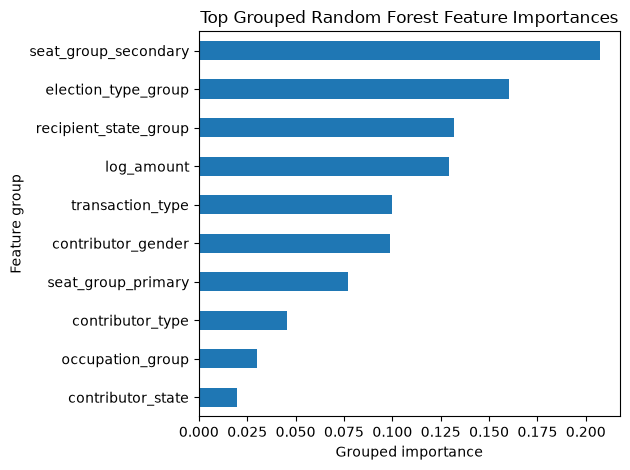

In [32]:
# Random Forest feature importance

rf_importance_df = random_forest_feature_importance_df(
    rf_cv_model,
    contrib_numeric_features,
    contrib_categorical_features,
    model_name="Random Forest"
)

print("Top Random" \
" Forest feature importances:")
show_df(rf_importance_df, 50, truncate=False)

rf_grouped_importance_df = group_ohe_importance(rf_importance_df, "importance")

print("Grouped Random Forest feature importances:")
show_df(rf_grouped_importance_df, 50, truncate=False)

if MAKE_GRAPHS:
    rf_imp_pd = rf_grouped_importance_df.limit(20).toPandas()
    if len(rf_imp_pd) > 0:
        ax = rf_imp_pd.sort_values("grouped_importance").plot(
            kind="barh",
            x="feature_group",
            y="grouped_importance",
            legend=False,
            title="Top Grouped Random Forest Feature Importances"
        )
        ax.set_xlabel("Grouped importance")
        ax.set_ylabel("Feature group")
        plt.tight_layout()
        plt.show()

Top Logistic Regression coefficient importances:
+------------------------------------+-------------------------------------+--------------------+
|model                               |feature                              |mean_abs_coefficient|
+------------------------------------+-------------------------------------+--------------------+
|Full Multinomial Logistic Regression|seat_group_secondary=COMMITTEE       |0.4275362952327561  |
|Full Multinomial Logistic Regression|election_type_group=\N               |0.29736778850689916 |
|Full Multinomial Logistic Regression|log_amount                           |0.2886449673470494  |
|Full Multinomial Logistic Regression|election_type_group=G                |0.2300168131161063  |
|Full Multinomial Logistic Regression|seat_group_secondary=LOWER           |0.22413727248485418 |
|Full Multinomial Logistic Regression|recipient_state_group=MA             |0.21394692169485605 |
|Full Multinomial Logistic Regression|seat_group_secondary=UPPER     

+------------------------------------+---------------------+-----------------------+
|model                               |feature_group        |grouped_coef_importance|
+------------------------------------+---------------------+-----------------------+
|Full Multinomial Logistic Regression|occupation_group     |4.356443038047382      |
|Full Multinomial Logistic Regression|recipient_state_group|2.6037416352175047     |
|Full Multinomial Logistic Regression|seat_group_secondary |1.7705311516052442     |
|Full Multinomial Logistic Regression|contributor_state    |1.1241006856036004     |
|Full Multinomial Logistic Regression|election_type_group  |0.7727766541510199     |
|Full Multinomial Logistic Regression|transaction_type     |0.7461852282526914     |
|Full Multinomial Logistic Regression|log_amount           |0.2886449673470494     |
|Full Multinomial Logistic Regression|seat_group_primary   |0.1699040041942275     |
|Full Multinomial Logistic Regression|contributor_gender   |0.162

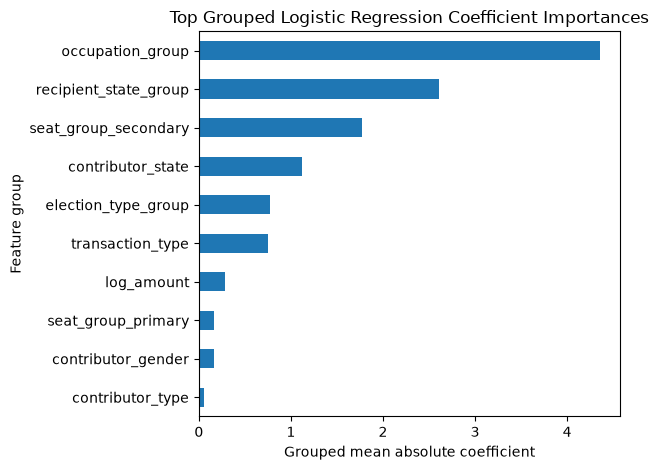

In [33]:
# Logistic Regression coefficient importance

full_lr_coef_importance_df = logistic_coefficient_importance_df(
    full_lr_cv_model,
    contrib_numeric_features,
    contrib_categorical_features,
    model_name="Full Multinomial Logistic Regression"
)

print("Top Logistic Regression coefficient importances:")
show_df(full_lr_coef_importance_df, 50, truncate=False)

full_lr_grouped_coef_importance_df = group_ohe_importance(
    full_lr_coef_importance_df.withColumnRenamed("mean_abs_coefficient", "coef_importance"),
    "coef_importance"
)

print("Grouped Logistic Regression coefficient importances:")
show_df(full_lr_grouped_coef_importance_df, 50, truncate=False)

if MAKE_GRAPHS:
    lr_imp_pd = full_lr_grouped_coef_importance_df.limit(20).toPandas()
    if len(lr_imp_pd) > 0:
        ax = lr_imp_pd.sort_values("grouped_coef_importance").plot(
            kind="barh",
            x="feature_group",
            y="grouped_coef_importance",
            legend=False,
            title="Top Grouped Logistic Regression Coefficient Importances"
        )
        ax.set_xlabel("Grouped mean absolute coefficient")
        ax.set_ylabel("Feature group")
        plt.tight_layout()
        plt.show()

In [ ]:
# 18. Model comparison and champion selection

metrics_rows = [benchmark_metrics, full_lr_metrics, rf_metrics, nb_metrics]
metrics_pdf = pd.DataFrame(metrics_rows)

model_comparison = spark.createDataFrame(metrics_pdf).orderBy(F.desc("weighted_f1"))

show_df(model_comparison, 20)

champion_row = model_comparison.first().asDict()
champion_model_name = champion_row["model"]

print("Champion model:", champion_model_name)
print("Champion weighted F1:", champion_row["weighted_f1"])
print("Champion weighted AUROC:", champion_row.get("weighted_ovr_auc"))

+------------------------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|model                               |accuracy          |weighted_f1       |weighted_precision|weighted_recall   |macro_ovr_auc     |weighted_ovr_auc  |
+------------------------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|Full Multinomial Logistic Regression|0.7765005911372739|0.7674260521750111|0.7670186704771705|0.7765005911372739|0.8950869574039763|0.8659201270339998|
|Naive Bayes                         |0.7291662797967231|0.7327169604798947|0.7376760771535703|0.7291662797967231|0.8621833661419648|0.8238290023763963|
|Benchmark Logistic Regression       |0.6810829882453436|0.6323510686103169|0.610304823280004 |0.6810829882453436|0.7251150214217795|0.755545740789541 |
|Random Forest                       |0.6707024939184045|0.5399756149071058|0.6854

## Champion Model Sensitivity Analysis

Hyperparameter sensitivity for the champion model selected above, pulled from that model's own cross-validation results table.

In [ ]:
# Champion model sensitivity analysis
# Re-displays the winning model's own CV results table (already computed in its section
# above) so hyperparameter sensitivity for the champion is explicit here, rather than only
# implicit back in that model's own section.
champion_cv_table_by_model = {
    "Benchmark Logistic Regression": benchmark_cv_table,
    "Full Multinomial Logistic Regression": full_lr_cv_table,
    "Random Forest": rf_cv_table,
    "Naive Bayes": nb_cv_table,
}

print(f"Hyperparameter sensitivity for champion model ({champion_model_name}):")
show_df(champion_cv_table_by_model[champion_model_name], 100)


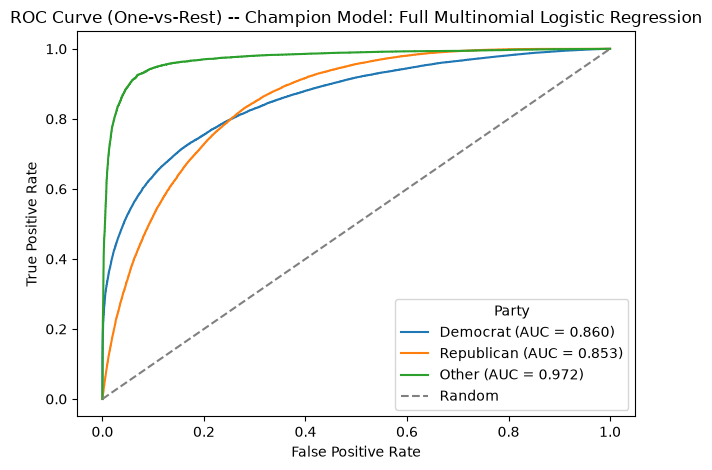

In [ ]:
# ROC curve (one-vs-rest) for the champion model
# Spark's DataFrame-based BinaryClassificationEvaluator only returns the scalar AUC, and
# this build's RDD-based BinaryClassificationMetrics doesn't expose .roc() either -- so the
# curve points are computed directly: collect (score, binary_label) per class, sort by score,
# and walk the cumulative true/false positive counts (same algorithm libraries like scikit-learn
# use internally).

def roc_curve_points(pred_df, class_index):
    prob_df = pred_df.withColumn("prob_array", vector_to_array(F.col("probability")))
    score_label_pd = (
        prob_df
        .select(
            F.col("prob_array")[class_index].alias("score"),
            F.when(F.col("label") == float(class_index), 1.0).otherwise(0.0).alias("binary_label"),
        )
        .filter(F.col("score").isNotNull())
        .toPandas()
    )

    scores = score_label_pd["score"].to_numpy()
    labels_binary = score_label_pd["binary_label"].to_numpy()
    n_pos = labels_binary.sum()
    n_neg = len(labels_binary) - n_pos
    if n_pos == 0 or n_neg == 0:
        return None, None, None

    order = np.argsort(-scores)
    labels_sorted = labels_binary[order]

    tpr = np.concatenate(([0.0], np.cumsum(labels_sorted) / n_pos))
    fpr = np.concatenate(([0.0], np.cumsum(1 - labels_sorted) / n_neg))
    try:
        # NumPy 2.0+
        auc = np.trapezoid(tpr, fpr)
    except AttributeError:
        # NumPy 1.x fallback
        auc = np.trapz(tpr, fpr)
    return fpr, tpr, auc

champion_pred_by_model = {
    "Benchmark Logistic Regression": (benchmark_pred, benchmark_labels),
    "Full Multinomial Logistic Regression": (full_lr_pred, full_lr_labels),
    "Random Forest": (rf_pred, rf_labels),
    "Naive Bayes": (nb_pred, nb_labels),
}
champion_pred, champion_labels = champion_pred_by_model[champion_model_name]

if MAKE_GRAPHS:
    fig, ax = plt.subplots()
    for i, label_name in enumerate(champion_labels):
        fpr, tpr, class_auc = roc_curve_points(champion_pred, i)
        if fpr is None:
            continue
        ax.plot(fpr, tpr, label=f"{label_name.title()} (AUC = {class_auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    ax.set_title(f"ROC Curve (One-vs-Rest) -- Champion Model: {champion_model_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(title="Party")
    plt.tight_layout()
    plt.show()

## Lift Chart (Champion Model)

One-vs-rest lift by decile for the champion model: how much more concentrated the true positives are in each decile of predicted probability versus the dataset's overall positive rate for that party.

In [ ]:
# Lift chart (one-vs-rest, by decile) for the champion model
# Ranks each class's predicted probability high-to-low, splits into equal-sized deciles,
# and reports how much more concentrated the true positives are in each decile versus the
# dataset's overall positive rate for that class. A lift of 2.0 in the top decile means the
# model's most-confident 10% of predictions contain 2x as many true positives as picking
# 10% at random would.

def lift_chart_points(pred_df, class_index, n_buckets=10):
    prob_df = pred_df.withColumn("prob_array", vector_to_array(F.col("probability")))
    score_label_pd = (
        prob_df
        .select(
            F.col("prob_array")[class_index].alias("score"),
            F.when(F.col("label") == float(class_index), 1.0).otherwise(0.0).alias("binary_label"),
        )
        .filter(F.col("score").isNotNull())
        .toPandas()
    )

    if len(score_label_pd) == 0:
        return None

    overall_rate = score_label_pd["binary_label"].mean()
    if overall_rate == 0:
        return None

    score_label_pd = score_label_pd.sort_values("score", ascending=False).reset_index(drop=True)
    score_label_pd["bucket"] = (np.arange(len(score_label_pd)) * n_buckets) // len(score_label_pd) + 1

    bucket_rate = score_label_pd.groupby("bucket")["binary_label"].mean()
    return (bucket_rate / overall_rate).reindex(range(1, n_buckets + 1))

if MAKE_GRAPHS:
    fig, ax = plt.subplots()
    for i, label_name in enumerate(champion_labels):
        lift = lift_chart_points(champion_pred, i)
        if lift is None:
            continue
        ax.plot(lift.index, lift.values, marker="o", label=label_name.title())
    ax.axhline(1.0, linestyle="--", color="gray", label="Random (lift = 1)")
    ax.set_title(f"Lift Chart (One-vs-Rest, by Decile) -- Champion Model: {champion_model_name}")
    ax.set_xlabel("Decile (1 = highest predicted probability)")
    ax.set_ylabel("Lift")
    ax.set_xticks(range(1, 11))
    ax.legend(title="Party")
    plt.tight_layout()
    plt.show()


# Save final outputs

In [ ]:
MODEL_OUTPUT_DIR = PROCESSED_DIR / f"final_project_outputs_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_comparison.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "model_comparison_parquet"))
benchmark_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "benchmark_cv_results_parquet"))
full_lr_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_cv_results_parquet"))
rf_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_cv_results_parquet"))

# Save model importance outputs
rf_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_feature_importance_parquet"))
rf_grouped_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_grouped_feature_importance_parquet"))
full_lr_coef_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_coefficient_importance_parquet"))
full_lr_grouped_coef_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_grouped_coefficient_importance_parquet"))

# Save EDA outputs
occupation_party_pct.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "occupation_party_pct_parquet"))
seat_primary_party_pct.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "seat_primary_party_pct_parquet"))
seat_secondary_party_pct.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "seat_secondary_party_pct_parquet"))
state_party_amount_pct.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "state_party_amount_pct_parquet"))
seat_party_median_amount.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "seat_party_median_amount_parquet"))
date_party_counts.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "date_party_counts_parquet"))

print("Saved outputs to:", MODEL_OUTPUT_DIR)